# Notebook de análisis y validación de simulaciones con foco en reward design

Este notebook organiza el análisis de una corrida como un flujo de validación experimental.
Primero verifica insumos y contexto, luego resume aprendizaje y restricciones físicas, después caracteriza la geometría teórica de la recompensa y finalmente contrasta esa teoría con la señal observada para cerrar en una propuesta de tuning.

El criterio rector del notebook es el siguiente:

1. **Validar qué experimento se está analizando y con qué artefactos cuenta.**
2. **Resumir cómo evolucionó la corrida y dónde estuvo el cuello de botella físico.**
3. **Caracterizar qué incentivo fue diseñado y qué región del espacio visitó realmente la política.**
4. **Cuantificar qué componentes y qué hiperparámetros dominaron la señal de aprendizaje.**
5. **Traducir el diagnóstico en cambios concretos y trazables para la siguiente corrida.**

Cada sección mantiene una celda editable de inputs para que el análisis siga siendo repetible, legible y reutilizable.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display, Markdown
except Exception:
    def display(obj):
        print(obj.to_string() if hasattr(obj, 'to_string') else obj)

    def Markdown(text):
        return text

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
from datetime import datetime


## 0. Selección base de la corrida

En esta etapa se selecciona la carpeta de resultados, el episodio de referencia y los parámetros globales de visualización.  
El notebook está pensado para leer directamente la estructura exportada por la simulación: `metadata.json`, `summary.xlsx` y `episodes_chunks_*.json`.

La regla de trabajo es la siguiente:

- La corrida fija el contexto metodológico.
- El episodio seleccionado fija la lectura principal detallada.
- Los perfiles cruzados pueden apoyarse en más de un episodio para evitar curvas vacías o poco representativas.


In [82]:
# ----------------------------
# Input global del notebook
# ----------------------------

RUNS_ROOT = Path("results_history_CartPole")
SYSTEM_FOLDER = "cart_pole"
RUN_ID = '20260418_1124'                             # None -> usa la última carpeta disponible
EPISODE_MODE = "best_total_reward"   # manual | last | best_total_reward | stabilization_success_best_reward
MANUAL_EPISODE_ID = 0

ROLLING_WINDOW = 15
PROFILE_BINS = 12
STEP_HEXBIN_SIZE = 50
INTERVAL_HEXBIN_SIZE = 25

CROSS_PROFILE_SCOPE = "best_total_reward_top_k"   # selected_episode | selected_plus_neighbors | best_total_reward_top_k | best_stabilization_success_top_k
CROSS_PROFILE_TOP_K = 12
CROSS_PROFILE_X_BINS = 60
CROSS_PROFILE_MIN_CURVE_POINTS = 80

SAVE_OUTPUTS = False
OUTPUT_FOLDER_NAME = ("analysis/" + RUN_ID) if RUN_ID is not None else ("analysis/" + "99999999_9999")


In [83]:
# ----------------------------
# Helpers base
# ----------------------------

def choose_run_dir(runs_root, system_folder, run_id):
    system_dir = runs_root / system_folder
    run_dirs = sorted([p for p in system_dir.iterdir() if p.is_dir()])
    return run_dirs[-1] if run_id is None else system_dir / run_id

def choose_episode_id(summary_df, mode, manual_id):
    if mode == "manual":
        return int(manual_id)
    if mode == "last":
        return int(summary_df["episode_id"].max())
    if mode == "best_total_reward":
        return int(summary_df.sort_values("total_reward", ascending=False).iloc[0]["episode_id"])
    success_df = summary_df[summary_df["end_termination_reason"] == "stabilization_success"]
    if len(success_df) > 0:
        return int(success_df.sort_values("total_reward", ascending=False).iloc[0]["episode_id"])
    return int(summary_df.sort_values("total_reward", ascending=False).iloc[0]["episode_id"])

def load_episode_by_id(run_dir, episode_id):
    chunk_files = sorted(run_dir.glob("episodes_chunks_*.json"))
    for chunk_path in chunk_files:
        with chunk_path.open("r", encoding="utf-8") as f:
            chunk_data = json.load(f)
        for episode_data in chunk_data:
            if int(episode_data["episode_id"]) == int(episode_id):
                return episode_data

def records_dict_to_frame(record_dict, scalar_keys):
    list_keys = [key for key, value in record_dict.items() if key not in scalar_keys and isinstance(value, list)]
    n_rows = max(len(record_dict[key]) for key in list_keys)
    out = {}
    for key in list_keys:
        values = list(record_dict[key])
        values = values + [np.nan] * (n_rows - len(values))
        out[key] = values
    return pd.DataFrame(out)

def choose_first_existing(candidates, columns):
    for candidate in candidates:
        if candidate in columns:
            return candidate

def reward_columns_for_var(interval_df, var_obj):
    return sorted([c for c in interval_df.columns if c.startswith("reward_") and c.endswith(var_obj)])

def coordination_columns_for_var(interval_df, var_obj):
    return sorted([c for c in interval_df.columns if ("coordination" in c) and c.endswith(var_obj)])

def extra_columns_for_var(interval_df, var_obj):
    all_extra = sorted([c for c in interval_df.columns if c.startswith("extra_") and c.endswith(var_obj)])
    coord_extra = coordination_columns_for_var(interval_df, var_obj)
    return [c for c in all_extra if c not in coord_extra and c != f"extra_total_{var_obj}"]

def assigned_reward_series(interval_df, var_obj):
    reward_cols = reward_columns_for_var(interval_df, var_obj)
    return interval_df[reward_cols].mean(axis=1)

def extract_active_var_objs(config_main):
    return [cfg["params"]["name_objective_var"] for cfg in config_main["controller_base"]["controllers"].values()]

def raw_state_range(config_main, var_obj):
    return config_main["dynamic_system"]["state_normalization"]["ranges_params"][var_obj]

def stabilization_band_raw(config_main, var_obj):
    criteria = config_main["dynamic_system"]["termination_conditions"]["stabilization_criteria"]
    if var_obj in criteria:
        return criteria[var_obj]
    return raw_state_range(config_main, var_obj)

def band_range(config_main, band_cfg, var_obj):
    key = f"error_{var_obj}"
    if key in band_cfg["ranges"]:
        return band_cfg["ranges"][key]
    return stabilization_band_raw(config_main, var_obj)

def metric_range_abs(normalization_cfg, var_obj, feature_key, fallback=1.0):
    params = normalization_cfg["params"]
    if var_obj in params and feature_key in params[var_obj]:
        low, high = params[var_obj][feature_key]["range"]
        return max(abs(low), abs(high))
    return fallback

def normalize_constant(normalization_cfg, var_obj, feature_key, level):
    params = normalization_cfg["params"]
    output_low, output_high = normalization_cfg["output_limits"]
    arr = np.asarray(level, dtype=float)

    if feature_key not in params[var_obj]:
        return np.zeros_like(arr)

    cfg = params[var_obj][feature_key]
    low, high = cfg["range"]
    method = cfg["method"]

    if method == "mean_squared":
        span = max(abs(low), abs(high)) ** 2
        value = np.square(np.abs(arr))
    elif method == "rms":
        span = max(abs(low), abs(high))
        value = np.abs(arr)
    elif method == "abs":
        span = max(abs(low), abs(high))
        value = np.abs(arr)
    elif method == "proportion":
        span = 1.0
        value = np.abs(arr)
    else:
        span = high - low
        value = np.abs(arr - low)

    normalized_01 = np.clip(value / span, 0.0, 1.0)
    return output_low + normalized_01 * (output_high - output_low)

def resolve_principal_gate_config(principal_cfg, feature_name, var_obj):
    if principal_cfg["method"] == "lineal_combination":
        gate_root = principal_cfg["lineal_combination_params"].get("feature_gates", {})
    else:
        gate_root = principal_cfg["weighted_exponential_params"].get("feature_gates", {})

    gate_cfg = gate_root.get(feature_name)
    if gate_cfg is None or not gate_cfg.get("enabled", False):
        return None

    resolved = dict(gate_cfg)
    per_var = resolved.pop("per_var", {})
    if var_obj in per_var:
        local = dict(resolved)
        local.update(per_var[var_obj])
        resolved = local

    source = resolved.get("source", "error_{var_obj}_mean_squared")
    resolved["source"] = source.format(var_obj=var_obj)
    return resolved

def gate_source_value(var_obj, source_key, error_level, edot_level, I_level=0.0, control_level=0.0, delta_u_eff_level=0.0):
    arr_error = np.asarray(error_level, dtype=float)
    arr_edot = np.asarray(edot_level, dtype=float)
    arr_I = np.asarray(I_level, dtype=float)
    arr_u = np.asarray(control_level, dtype=float)
    arr_delta_u = np.asarray(delta_u_eff_level, dtype=float)

    source_map = {
        f"error_{var_obj}": arr_error,
        f"error_{var_obj}_mean_squared": np.square(np.abs(arr_error)),
        f"L_e_{var_obj}": np.square(np.abs(arr_error)),
        f"derivative_error_{var_obj}": arr_edot,
        f"derivative_error_{var_obj}_mean_squared": np.square(np.abs(arr_edot)),
        f"L_edot_{var_obj}": np.square(np.abs(arr_edot)),
        f"integral_error_{var_obj}": arr_I,
        f"integral_error_{var_obj}_mean_squared": np.square(np.abs(arr_I)),
        f"L_I_{var_obj}": np.square(np.abs(arr_I)),
        f"u_eff_{var_obj}": arr_u,
        f"u_eff_{var_obj}_mean_squared": np.square(np.abs(arr_u)),
        f"L_u_{var_obj}": np.square(np.abs(arr_u)),
        f"delta_u_eff_{var_obj}": arr_delta_u,
        f"delta_u_eff_{var_obj}_mean_squared": np.square(np.abs(arr_delta_u)),
        f"L_delta_u_{var_obj}": np.square(np.abs(arr_delta_u)),
    }
    return source_map[source_key]

def principal_feature_value(normalization_cfg, var_obj, feature_name, error_level, edot_level, I_level=0.0, control_level=0.0, delta_u_eff_level=0.0):
    feature_source_map = {
        "L_e": ("e", error_level),
        "L_edot": ("edot", edot_level),
        "L_I": ("I", I_level),
        "L_u": ("u", control_level),
        "L_delta_u": ("delta_u", delta_u_eff_level),
    }
    metric_key, level = feature_source_map[feature_name]
    return normalize_constant(normalization_cfg, var_obj, metric_key, level)

def principal_gate_factor(principal_cfg, normalization_cfg, var_obj, feature_name, error_level, edot_level, I_level=0.0, control_level=0.0, delta_u_eff_level=0.0):
    gate_cfg = resolve_principal_gate_config(principal_cfg, feature_name, var_obj)
    if gate_cfg is None:
        return np.ones_like(np.asarray(error_level, dtype=float))

    value = gate_source_value(
        var_obj=var_obj,
        source_key=gate_cfg["source"],
        error_level=error_level,
        edot_level=edot_level,
        I_level=I_level,
        control_level=control_level,
        delta_u_eff_level=delta_u_eff_level,
    )
    if gate_cfg.get("use_abs", True):
        value = np.abs(value)
    if gate_cfg.get("use_sqrt", False):
        value = np.sqrt(np.maximum(value, 0.0))

    gain = gate_cfg.get("strength", gate_cfg.get("scaled", 1.0))
    setpoint = gate_cfg.get("x_sp", gate_cfg.get("setpoint", 0.0))
    factor_type = gate_cfg.get("type", "exp")

    if factor_type == "exp":
        factor = np.exp(-(((value - setpoint) / gain) ** 2)) if gain > 0 else np.zeros_like(value)
    else:
        factor = np.tanh(gain * np.abs(value - setpoint))

    if gate_cfg.get("invert", False):
        factor = 1.0 - factor

    return np.clip(factor, gate_cfg.get("min_factor", 0.0), gate_cfg.get("max_factor", 1.0))

def principal_loop_reward(principal_cfg, normalization_cfg, principal_features, var_obj, error_level, edot_level, I_level=0.0, control_level=0.0, delta_u_eff_level=0.0):
    total = 0.0
    for feature_name, feature_cfg in principal_features.items():
        feature_value = principal_feature_value(
            normalization_cfg=normalization_cfg,
            var_obj=var_obj,
            feature_name=feature_name,
            error_level=error_level,
            edot_level=edot_level,
            I_level=I_level,
            control_level=control_level,
            delta_u_eff_level=delta_u_eff_level,
        )
        gate_factor = principal_gate_factor(
            principal_cfg=principal_cfg,
            normalization_cfg=normalization_cfg,
            var_obj=var_obj,
            feature_name=feature_name,
            error_level=error_level,
            edot_level=edot_level,
            I_level=I_level,
            control_level=control_level,
            delta_u_eff_level=delta_u_eff_level,
        )

        if principal_cfg["method"] == "lineal_combination":
            total = total - feature_cfg["weight"] * gate_factor * feature_value
        else:
            scaled = feature_cfg["scaled"]
            setpoint = feature_cfg.get("setpoint", 0.0)
            total = total - gate_factor * feature_cfg["weight"] * (1.0 - np.exp(-scaled * (feature_value - setpoint) ** 2))
    return total

def band_bonus(config_main, band_cfg, decision_steps, var_obj, error_level):
    if not band_cfg["enabled"]:
        return np.zeros_like(np.asarray(error_level, dtype=float))
    low, high = band_range(config_main, band_cfg, var_obj)
    limit = max(abs(low), abs(high))
    raw = np.where(np.abs(np.asarray(error_level, dtype=float)) <= limit, decision_steps * band_cfg["per_step_band_bonus"], 0.0)
    return np.minimum(raw, band_cfg["max_total_band_bonus"][var_obj])

def dynamic_penalty(extra_cfg, var_obj, control_level, error_level):
    dyn_pen_cfg = extra_cfg["conditional_approach"]["dynamic_penalty"]
    if not dyn_pen_cfg["enabled"]:
        return np.zeros_like(np.asarray(control_level, dtype=float))

    params = dyn_pen_cfg["dynamic_penalty_params"]
    key_candidates = [f"control_action_{var_obj}", f"u_eff_{var_obj}", f"delta_control_action_{var_obj}"]
    signal_key = [k for k in key_candidates if k in params][0]
    cfg = params[signal_key]

    control_abs = np.abs(np.asarray(control_level, dtype=float))
    error_abs = np.abs(np.asarray(error_level, dtype=float))
    cond = cfg["condition"]

    gain = cond.get("strength", cond.get("scaled", 1.0))
    setpoint = cond.get("x_sp", cond.get("setpoint", 0.0))
    cond_type = cond.get("type", "exp")

    if cond_type == "exp":
        factor = np.exp(-(((error_abs - setpoint) / gain) ** 2)) if gain > 0 else np.zeros_like(error_abs)
    else:
        factor = np.tanh(gain * np.abs(error_abs - setpoint))

    if dyn_pen_cfg["method"] == "quadratic":
        return -cfg["weight"] * (control_abs ** 2) * factor
    return -cfg["weight"] * control_abs * factor

def total_loop_proxy(config_main, principal_cfg, normalization_cfg, principal_features, extra_cfg, decision_steps, var_obj, error_level, control_level, edot_level=0.0):
    band_cfg = extra_cfg["bonus_approach"]["bandwidth_bonus"]
    return (
        principal_loop_reward(principal_cfg, normalization_cfg, principal_features, var_obj, error_level, edot_level, control_level=control_level, delta_u_eff_level=control_level)
        + band_bonus(config_main, band_cfg, decision_steps, var_obj, error_level)
        + dynamic_penalty(extra_cfg, var_obj, control_level, error_level)
    )

def build_variable_catalog(config_main, step_df, interval_df):
    active_var_objs = extract_active_var_objs(config_main)
    rows = []
    for var_obj in active_var_objs:
        rows.append({
            "var_obj": var_obj,
            "raw_state_col": choose_first_existing([f"{var_obj}_raw", var_obj], step_df.columns),
            "error_col": choose_first_existing([f"error_{var_obj}"], step_df.columns),
            "derivative_error_col": choose_first_existing([f"derivative_error_{var_obj}", f"delta_error_{var_obj}"], step_df.columns),
            "integral_error_col": choose_first_existing([f"integral_error_{var_obj}"], step_df.columns),
            "control_action_col": choose_first_existing([f"control_action_{var_obj}", f"u_eff_{var_obj}", "u_total"], step_df.columns),
            "delta_u_col": choose_first_existing([f"delta_u_eff_{var_obj}", f"delta_control_action_{var_obj}", "delta_u_total"], step_df.columns),
            "reward_cols": reward_columns_for_var(interval_df, var_obj),
            "extra_cols": extra_columns_for_var(interval_df, var_obj),
            "coordination_cols": coordination_columns_for_var(interval_df, var_obj),
            "stabilization_band_raw": stabilization_band_raw(config_main, var_obj),
        })
    catalog_df = pd.DataFrame(rows)
    catalog_df["reward_assignment_mode"] = "mean_over_reward_columns"
    return catalog_df

def build_behavior_df(interval_df, step_df, variable_catalog):
    df = interval_df.copy()
    var_objs = list(variable_catalog["var_obj"])

    for var_obj in var_objs:
        extra_cols = variable_catalog.loc[variable_catalog["var_obj"] == var_obj, "extra_cols"].iloc[0]
        coord_cols = variable_catalog.loc[variable_catalog["var_obj"] == var_obj, "coordination_cols"].iloc[0]

        df[f"extra_total_{var_obj}"] = df[extra_cols].sum(axis=1) if len(extra_cols) > 0 else 0.0
        df[f"coordination_total_{var_obj}"] = df[coord_cols].sum(axis=1) if len(coord_cols) > 0 else 0.0
        df[f"assigned_reward_{var_obj}"] = assigned_reward_series(df, var_obj)
        df[f"principal_loop_{var_obj}"] = df[f"assigned_reward_{var_obj}"] - df[f"extra_total_{var_obj}"] - df[f"coordination_total_{var_obj}"]

    rows = []
    for _, interval_row in df.iterrows():
        start_idx = int(interval_row["interval_start_step_idx"])
        end_idx = int(interval_row["interval_end_step_idx"])
        step_slice = step_df.iloc[start_idx:end_idx + 1].copy()
        out_row = interval_row.to_dict()

        for _, meta in variable_catalog.iterrows():
            var_obj = meta["var_obj"]
            out_row[f"mean_abs_error_{var_obj}"] = float(step_slice[meta["error_col"]].abs().mean())
            out_row[f"mean_abs_control_action_{var_obj}"] = float(step_slice[meta["control_action_col"]].abs().mean())
            out_row[f"mean_abs_raw_state_{var_obj}"] = float(step_slice[meta["raw_state_col"]].abs().mean())

        rows.append(out_row)

    out = pd.DataFrame(rows)
    out["principal_total_rebuilt"] = out[[f"principal_loop_{var_obj}" for var_obj in var_objs]].sum(axis=1)
    out["extra_total_rebuilt"] = out[[f"extra_total_{var_obj}" for var_obj in var_objs]].sum(axis=1)
    out["coordination_total_rebuilt"] = out[[f"coordination_total_{var_obj}" for var_obj in var_objs]].sum(axis=1)
    out["global_reward_rebuilt"] = out["principal_total_rebuilt"] + out["extra_total_rebuilt"] + out["coordination_total_rebuilt"]
    return out

def build_step_reward_df_from_episode(episode_data, variable_catalog):
    step_df = records_dict_to_frame(episode_data["step_data"], scalar_keys={"n_step"})
    interval_df = records_dict_to_frame(episode_data["interval_data"], scalar_keys={"n_interval"})
    var_objs = list(variable_catalog["var_obj"])

    step_df["global_reward_per_step"] = np.nan
    for var_obj in var_objs:
        step_df[f"assigned_reward_per_step_{var_obj}"] = np.nan

    for idx, interval_row in interval_df.iterrows():
        start_idx = int(interval_row["interval_start_step_idx"])
        end_idx = int(interval_row["interval_end_step_idx"])
        n_steps = int(interval_row["interval_n_steps"])
        step_df.loc[start_idx:end_idx, "global_reward_per_step"] = float(interval_row["global_interval_reward"]) / n_steps

        for var_obj in var_objs:
            interval_reward = float(assigned_reward_series(interval_df, var_obj).iloc[idx])
            step_df.loc[start_idx:end_idx, f"assigned_reward_per_step_{var_obj}"] = interval_reward / n_steps

    step_df["episode_id"] = int(episode_data["episode_id"])
    return step_df

def select_profile_episode_ids(summary_df, mode, selected_episode_id, top_k):
    if mode == "selected_episode":
        return [int(selected_episode_id)]
    if mode == "selected_plus_neighbors":
        ordered = summary_df.sort_values("episode_id").reset_index(drop=True)
        row_idx = int(ordered.index[ordered["episode_id"] == selected_episode_id][0])
        low = max(0, row_idx - top_k // 2)
        high = min(len(ordered), row_idx + top_k // 2 + 1)
        return [int(v) for v in ordered.iloc[low:high]["episode_id"].tolist()]
    if mode == "best_total_reward_top_k":
        return [int(v) for v in summary_df.sort_values("total_reward", ascending=False).head(top_k)["episode_id"].tolist()]
    success_df = summary_df[summary_df["end_termination_reason"] == "stabilization_success"]
    source_df = success_df if len(success_df) > 0 else summary_df
    return [int(v) for v in source_df.sort_values("total_reward", ascending=False).head(top_k)["episode_id"].tolist()]

def build_cross_profile_df(run_dir, summary_df, selected_episode_id, variable_catalog, mode, top_k):
    episode_ids = select_profile_episode_ids(summary_df, mode, selected_episode_id, top_k)
    frames = []
    for episode_id in episode_ids:
        episode_data = load_episode_by_id(run_dir, episode_id)
        frames.append(build_step_reward_df_from_episode(episode_data, variable_catalog))
    return pd.concat(frames, ignore_index=True)

def profile(frame, x_col, y_cols, bins):
    valid = frame[[x_col] + y_cols].dropna().copy()
    groups = valid.groupby(pd.cut(valid[x_col], bins=bins, duplicates="drop"), observed=False)[y_cols].mean()
    x_mid = [interval.mid for interval in groups.index]
    groups.insert(0, x_col, x_mid)
    return groups.reset_index(drop=True)

def cross_slice_values(series, manual_values=None, n_levels=5):
    if manual_values is not None:
        return [float(v) for v in manual_values]
    clean = pd.Series(series).dropna().astype(float)
    quantiles = np.linspace(0.10, 0.90, n_levels)
    return [float(v) for v in np.nanquantile(clean, quantiles)]

def plot_cross_reward_profiles(ax, frame, x_col, slice_col, reward_col, target_var, slice_label, title, x_label, stabilization_band, slice_values, x_bins, min_curve_points):
    local = frame[[x_col, slice_col, reward_col]].dropna().copy()
    slice_vals = cross_slice_values(local[slice_col], slice_values)
    sorted_vals = np.sort(np.unique(np.asarray(slice_vals, dtype=float)))
    slice_midpoints = (sorted_vals[:-1] + sorted_vals[1:]) / 2.0

    support_rows = []
    x_low, x_high = np.nanquantile(local[x_col], [0.01, 0.99])
    bins = np.linspace(x_low, x_high, x_bins)

    for idx, slice_value in enumerate(sorted_vals):
        left = float(local[slice_col].min()) if idx == 0 else float(slice_midpoints[idx - 1])
        right = float(local[slice_col].max()) if idx == len(sorted_vals) - 1 else float(slice_midpoints[idx])

        if idx == len(sorted_vals) - 1:
            subset = local[(local[slice_col] >= left) & (local[slice_col] <= right)].copy()
        else:
            subset = local[(local[slice_col] >= left) & (local[slice_col] < right)].copy()

        support_rows.append({
            "target_var": target_var,
            "slice_label": slice_label,
            "slice_value": float(subset[slice_col].median()) if len(subset) > 0 else float(slice_value),
            "slice_low": left,
            "slice_high": right,
            "n_points": int(len(subset)),
            "x_min": float(subset[x_col].min()) if len(subset) > 0 else np.nan,
            "x_max": float(subset[x_col].max()) if len(subset) > 0 else np.nan,
        })

        if len(subset) >= min_curve_points:
            grouped_mean = subset.groupby(pd.cut(subset[x_col], bins=bins, include_lowest=True), observed=False)[reward_col].mean()
            grouped_count = subset.groupby(pd.cut(subset[x_col], bins=bins, include_lowest=True), observed=False)[reward_col].count()
            valid = (grouped_count >= 3) & grouped_mean.notna()
            centers = np.array([interval.mid for interval in grouped_mean.index[valid]])
            ax.plot(centers, grouped_mean[valid].values, label=f"{slice_label}={support_rows[-1]['slice_value']:.3f}")

    band_low, band_high = stabilization_band
    ax.axvspan(band_low, band_high, alpha=0.15, color="lightsteelblue")
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(reward_col)
    ax.legend()
    return pd.DataFrame(support_rows)

def coordination_partial_potential_map(coord_cfg, error_grid, edot_grid, var_obj):
    weights_e = coord_cfg["potential_weights"]["L_e"][var_obj]
    weights_edot = coord_cfg["potential_weights"]["L_edot"][var_obj]
    return weights_e * error_grid + weights_edot * edot_grid

def coordination_progress_rewardable(coord_cfg, delta_phi):
    progress = np.asarray(delta_phi, dtype=float)
    if coord_cfg["progress_positive_only"]:
        progress = np.maximum(progress, 0.0)
    return np.minimum(progress, coord_cfg["progress_clip_max"])

def coordination_credit_share(raw_values, other_raw, epsilon_credit):
    raw_values = np.asarray(raw_values, dtype=float)
    return raw_values / (epsilon_credit + raw_values + other_raw)

def coordination_reward_curve(global_weight, progress_value, credit_share):
    return global_weight * progress_value * credit_share

# ----------------------------
# Helpers de persistencia y trazabilidad
# ----------------------------

def human_size(num_bytes):
    num = float(num_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if num < 1024.0 or unit == "TB":
            return f"{num:.2f} {unit}"
        num /= 1024.0

def slugify(text):
    safe = "".join(ch if ch.isalnum() else "_" for ch in str(text).lower())
    while "__" in safe:
        safe = safe.replace("__", "_")
    return safe.strip("_")

def prepare_analysis_dirs(root_dir, save_outputs):
    root = Path(root_dir)
    subdirs = {
        "manifest": root / "manifest",
        "hyperparameters": root / "hyperparameters",
        "summary": root / "summary",
        "learning": root / "learning",
        "episodes": root / "episodes",
        "reward_behavior": root / "reward_behavior",
        "comparison": root / "comparison",
        "decision_report": root / "decision_report",
    }
    if save_outputs:
        root.mkdir(parents=True, exist_ok=True)
        for path in subdirs.values():
            path.mkdir(parents=True, exist_ok=True)
    return root, subdirs

def export_table(df, folder, stem, index=False, markdown_too=False, excel=False):
    if not SAVE_OUTPUTS or df is None:
        return
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    stem = slugify(stem)
    df.to_csv(folder / f"{stem}.csv", index=index, encoding="utf-8")
    if excel:
        df.to_excel(folder / f"{stem}.xlsx", index=index)
    if markdown_too:
        try:
            text = df.to_markdown(index=index)
        except Exception:
            text = df.to_string(index=index)
        (folder / f"{stem}.md").write_text(text, encoding="utf-8")

def export_text(text, path):
    if not SAVE_OUTPUTS:
        return
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(str(text), encoding="utf-8")

def export_figure(fig, folder, stem, dpi=160):
    if not SAVE_OUTPUTS or fig is None:
        return
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    stem = slugify(stem)
    fig.savefig(folder / f"{stem}.png", bbox_inches="tight", dpi=dpi)

def absolute_peak_from_summary(frame, prefix):
    min_col = choose_first_existing([f"{prefix}_min"], frame.columns)
    max_col = choose_first_existing([f"{prefix}_max"], frame.columns)
    if min_col is None or max_col is None:
        return pd.Series(np.nan, index=frame.index)
    return pd.concat([frame[min_col].abs(), frame[max_col].abs()], axis=1).max(axis=1)

def flatten_config_scalars(obj, prefix=""):
    rows = []
    if isinstance(obj, dict):
        for key, value in obj.items():
            new_prefix = f"{prefix}.{key}" if prefix else key
            rows.extend(flatten_config_scalars(value, new_prefix))
        return rows
    if isinstance(obj, (list, tuple)):
        if all(not isinstance(value, (dict, list, tuple)) for value in obj):
            rows.append({"path": prefix, "value": json.dumps(list(obj), ensure_ascii=False)})
        else:
            for index, value in enumerate(obj):
                rows.extend(flatten_config_scalars(value, f"{prefix}[{index}]"))
        return rows
    rows.append({"path": prefix, "value": obj})
    return rows

def hyperparameter_block(path):
    if path.startswith("reward_base.reward_calculation.principal_reward"):
        return "principal_reward"
    if path.startswith("reward_base.reward_calculation.extra_rewards"):
        return "extra_rewards"
    if path.startswith("reward_base.reward_calculation.coordination_reward"):
        return "coordination_reward"
    if path.startswith("agent_base"):
        return "training"
    if path.startswith("dynamic_system.termination_conditions"):
        return "termination"
    if path.startswith("simulation"):
        return "simulation"
    return "other"

def hyperparameter_role(path):
    if ".features." in path and path.endswith(".weight"):
        return "Escala la influencia relativa de una feature del reward principal."
    if ".features." in path and path.endswith(".scaled"):
        return "Controla la rapidez con la que una penalización se vuelve severa."
    if ".features." in path and path.endswith(".setpoint"):
        return "Desplaza el punto de mayor atractivo de la feature."
    if "bandwidth_bonus.per_step_band_bonus" in path:
        return "Premia permanencia dentro de banda por intervalo."
    if "bandwidth_bonus.max_total_band_bonus" in path:
        return "Limita el aporte máximo del bonus de banda."
    if "dynamic_penalty" in path:
        return "Penaliza esfuerzo o agresividad cuando se cumplen condiciones de activación."
    if "dynamic_incentive" in path:
        return "Refuerza zonas de transición consideradas útiles por diseño."
    if "coordination_reward.global_weight" in path:
        return "Escala la autoridad del bloque coordinativo frente al reward total."
    if "coordination_reward.progress_clip_max" in path:
        return "Satura el progreso coordinativo premiable."
    if "coordination_reward.epsilon_credit" in path:
        return "Regula reparto de crédito cuando las contribuciones son pequeñas."
    if path.startswith("agent_base") and "epsilon" in path:
        return "Regula la exploración del agente durante el aprendizaje."
    if path.startswith("dynamic_system.termination_conditions"):
        return "Define criterios de éxito, estabilidad y terminación física."
    if path.startswith("simulation"):
        return "Define la resolución temporal y la duración del experimento."
    return "Parámetro activo sin descripción heurística específica."

def hyperparameter_signals(path):
    hits = []
    for candidate in ["pendulum_angle", "pendulum_velocity", "cart_position", "cart_velocity", "u_total", "performance", "total_reward"]:
        if candidate in path:
            hits.append(candidate)
    if ".features.L_e" in path:
        hits.append("error")
    if ".features.L_edot" in path:
        hits.append("derivative_error")
    if ".features.L_u" in path:
        hits.append("u_eff")
    if ".features.L_I" in path:
        hits.append("integral_error")
    if "coordination_reward" in path:
        hits.extend(["u_eff", "progress", "u_total"])
    if "bandwidth_bonus" in path:
        hits.append("stabilization_band")
    return ", ".join(dict.fromkeys(hits)) if hits else "config_only"


## 1. Contexto de la corrida y contrato de datos

Esta sección fija el terreno del análisis.  
Antes de estudiar superficies, perfiles o mapas, conviene dejar explícito qué reward se ejecutó, qué bloques están activos, qué lazos existen y qué columnas canónicas quedaron registradas.

La finalidad de esta sección es doble:

- evitar interpretaciones apoyadas en supuestos incorrectos;
- transformar la corrida en un contrato legible que guíe el resto del notebook.


In [84]:
# ----------------------------
# Input de la sección 1
# ----------------------------

SECTION_CONTEXT_TARGET_VARS = None    # None -> usa todas las variables objetivo detectadas


In [85]:
# ----------------------------
# Contexto de corrida y contrato
# ----------------------------

RUN_DIR = choose_run_dir(RUNS_ROOT, SYSTEM_FOLDER, RUN_ID)
RUN_ID = RUN_DIR.name

with (RUN_DIR / "metadata.json").open("r", encoding="utf-8") as f:
    run_metadata = json.load(f)

config_main = run_metadata["config_main"]
reward_base_cfg = config_main["reward_base"]
reward_cfg = reward_base_cfg["reward_config"]
reward_calc_cfg = reward_base_cfg["reward_calculation"]
principal_cfg = reward_calc_cfg["principal_reward"]
extra_cfg = reward_calc_cfg["extra_rewards"]
coord_cfg = reward_calc_cfg["coordination_reward"]
normalization_cfg = reward_calc_cfg["metric_processing"]["normalization"]

summary_df = pd.read_excel(RUN_DIR / "summary.xlsx")
selected_episode_id = choose_episode_id(summary_df, EPISODE_MODE, MANUAL_EPISODE_ID)
selected_episode = load_episode_by_id(RUN_DIR, selected_episode_id)

step_df = records_dict_to_frame(selected_episode["step_data"], scalar_keys={"n_step"})
interval_df = records_dict_to_frame(selected_episode["interval_data"], scalar_keys={"n_interval"})

active_var_objs = extract_active_var_objs(config_main)
if SECTION_CONTEXT_TARGET_VARS is None:
    target_var_objs = active_var_objs
else:
    target_var_objs = SECTION_CONTEXT_TARGET_VARS

principal_features = principal_cfg["lineal_combination_params"]["features"] if principal_cfg["method"] == "lineal_combination" else principal_cfg["weighted_exponential_params"]["features"]
band_cfg = extra_cfg["bonus_approach"]["bandwidth_bonus"]
decision_steps = int(config_main["simulation"]["decision_interval_sec"] / config_main["simulation"]["dt_sec"])

variable_catalog_df = build_variable_catalog(config_main, step_df, interval_df)
variable_catalog_df = variable_catalog_df[variable_catalog_df["var_obj"].isin(target_var_objs)].reset_index(drop=True)

overview_df = pd.DataFrame([{
    "run_dir": str(RUN_DIR),
    "run_id": RUN_ID,
    "selected_episode_id": int(selected_episode_id),
    "reward_approach": reward_cfg["reward_approach"],
    "principal_method": principal_cfg["method"],
    "extra_rewards_enabled": extra_cfg["enabled"],
    "coordination_enabled": coord_cfg["enabled"],
    "n_target_vars": len(target_var_objs),
    "n_intervals": int(interval_df["interval_id"].nunique()),
    "n_steps": int(step_df.shape[0]),
}])

reward_blocks_df = pd.DataFrame([
    {"block": "principal_reward", "enabled": principal_cfg["enabled"], "method": principal_cfg["method"]},
    {"block": "extra_rewards", "enabled": extra_cfg["enabled"], "method": "mixed"},
    {"block": "bandwidth_bonus", "enabled": extra_cfg["bonus_approach"]["bandwidth_bonus"]["enabled"], "method": "band_bonus"},
    {"block": "goal_bonus_reward", "enabled": extra_cfg["bonus_approach"]["goal_bonus_reward"]["enabled"], "method": extra_cfg["bonus_approach"]["goal_bonus_reward"]["method"]},
    {"block": "dynamic_penalty", "enabled": extra_cfg["conditional_approach"]["dynamic_penalty"]["enabled"], "method": extra_cfg["conditional_approach"]["dynamic_penalty"]["method"]},
    {"block": "dynamic_incentive", "enabled": extra_cfg["conditional_approach"]["dynamic_incentive"]["enabled"], "method": extra_cfg["conditional_approach"]["dynamic_incentive"]["method"]},
    {"block": "coordination_reward", "enabled": coord_cfg["enabled"], "method": coord_cfg["reward_name"]},
])

principal_df = pd.DataFrame(principal_features).T.rename_axis("feature").reset_index()

display(Markdown("**Vista general de la corrida**"))
display(overview_df)

display(Markdown("**Bloques de reward activos**"))
display(reward_blocks_df)

display(Markdown("**Parámetros de la reward principal**"))
display(principal_df)

display(Markdown("**Catálogo de variables y columnas canónicas**"))
display(variable_catalog_df)

OUTPUT_FOLDER_NAME = str(Path("analysis") / RUN_ID)
ANALYSIS_OUTPUT_DIR, ANALYSIS_SUBDIRS = prepare_analysis_dirs(Path(OUTPUT_FOLDER_NAME), SAVE_OUTPUTS)
tables_xlsx_path = ANALYSIS_OUTPUT_DIR / "analysis_results.xlsx"
termination_col = choose_first_existing(["end_termination_reason", "termination_reason"], summary_df.columns)


**Vista general de la corrida**

,run_dir,run_id,selected_episode_id,reward_approach,principal_method,extra_rewards_enabled,coordination_enabled,n_target_vars,n_intervals,n_steps
0,results_history_CartPole\cart_pole\20260418_1124,20260418_1124,1967,controller_reward,weighted_exponential,True,True,2,79,1565


**Bloques de reward activos**

,block,enabled,method
0,principal_reward,True,weighted_exponential
1,extra_rewards,True,mixed
2,bandwidth_bonus,False,band_bonus
3,goal_bonus_reward,True,decay
4,dynamic_penalty,False,quadratic
5,dynamic_incentive,False,adaptative
6,coordination_reward,True,coordination_global_progress


**Parámetros de la reward principal**

,feature,weight,scaled,setpoint
0,L_e,0.75,6.5,0.0
1,L_edot,0.15,1.8,0.0
2,L_I,0.00,1.0,0.0
3,L_u,0.10,2.0,0.0


**Catálogo de variables y columnas canónicas**

,var_obj,raw_state_col,error_col,derivative_error_col,integral_error_col,control_action_col,delta_u_col,reward_cols,extra_cols,coordination_cols,stabilization_band_raw,reward_assignment_mode
0,pendulum_angle,pendulum_angle_raw,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,control_action_pendulum_angle,delta_u_eff_pendulum_angle,"[reward_kd_pendulum_angle, reward_ki_pendulum_...","[extra_bonus_band_pendulum_angle, extra_bonus_...","[coordination_credit_raw_pendulum_angle, coord...","[-0.02, 0.02]",mean_over_reward_columns
1,cart_position,cart_position_raw,error_cart_position,derivative_error_cart_position,integral_error_cart_position,control_action_cart_position,delta_u_eff_cart_position,"[reward_kd_cart_position, reward_ki_cart_posit...","[extra_bonus_band_cart_position, extra_bonus_g...","[coordination_credit_raw_cart_position, coordi...","[-0.1, 0.1]",mean_over_reward_columns


## 1A. Manifiesto de insumos y control de consistencia

Antes de interpretar métricas o superficies, conviene verificar qué archivos están presentes, cuánto pesan y si la corrida ofrece el material mínimo necesario para una auditoría seria.


In [86]:
required_input_paths = [
    RUN_DIR / "metadata.json",
    RUN_DIR / "summary.xlsx",
]
chunk_paths = sorted(RUN_DIR.glob("episodes_chunks_*.json"))
manifest_rows = []

for path in required_input_paths + chunk_paths:
    manifest_rows.append(
        {
            "artifact": path.name,
            "kind": "chunk" if path.name.startswith("episodes_chunks_") else "core_input",
            "exists": path.exists(),
            "size_bytes": int(path.stat().st_size) if path.exists() else np.nan,
            "size_human": human_size(int(path.stat().st_size)) if path.exists() else "missing",
            "modified_at": datetime.fromtimestamp(path.stat().st_mtime).isoformat(timespec="seconds") if path.exists() else "",
        }
    )

manifest_df = pd.DataFrame(manifest_rows)
manifest_summary_df = pd.DataFrame(
    [
        {
            "run_id": RUN_ID,
            "run_dir": str(RUN_DIR),
            "required_inputs_ok": all(path.exists() for path in required_input_paths),
            "n_chunk_files": len(chunk_paths),
            "n_summary_episodes": int(len(summary_df)),
            "selected_episode_id": int(selected_episode_id),
            "selected_episode_found": selected_episode is not None,
        }
    ]
)

display(Markdown("**Resumen del manifiesto**"))
display(manifest_summary_df)
display(Markdown("**Inventario de archivos de entrada**"))
display(manifest_df)

export_table(
    manifest_summary_df,
    ANALYSIS_SUBDIRS["manifest"],
    "00_manifest_summary",
    markdown_too=True,
    excel=True,
)
export_table(
    manifest_df,
    ANALYSIS_SUBDIRS["manifest"],
    "01_input_manifest",
    markdown_too=True,
    excel=True,
)


**Resumen del manifiesto**

,run_id,run_dir,required_inputs_ok,n_chunk_files,n_summary_episodes,selected_episode_id,selected_episode_found
0,20260418_1124,results_history_CartPole\cart_pole\20260418_1124,True,50,5000,1967,True


**Inventario de archivos de entrada**

,artifact,kind,exists,size_bytes,size_human,modified_at
0,metadata.json,core_input,True,47382,46.27 KB,2026-04-18T11:24:13
1,summary.xlsx,core_input,True,21993441,20.97 MB,2026-04-18T11:56:49
2,episodes_chunks_0000.json,chunk,True,142564420,135.96 MB,2026-04-18T11:24:43
3,episodes_chunks_0001.json,chunk,True,142386644,135.79 MB,2026-04-18T11:25:13
4,episodes_chunks_0002.json,chunk,True,153754353,146.63 MB,2026-04-18T11:25:46
5,episodes_chunks_0003.json,chunk,True,166495266,158.78 MB,2026-04-18T11:26:22
6,episodes_chunks_0004.json,chunk,True,156194310,148.96 MB,2026-04-18T11:26:56
7,episodes_chunks_0005.json,chunk,True,150130639,143.18 MB,2026-04-18T11:27:29
8,episodes_chunks_0006.json,chunk,True,152131457,145.08 MB,2026-04-18T11:28:03
9,episodes_chunks_0007.json,chunk,True,146861703,140.06 MB,2026-04-18T11:28:36


## 1B. Resumen global de resultados

Esta vista compacta responde primero lo esencial: cómo le fue a la corrida en términos agregados, cuáles fueron las terminaciones dominantes y qué episodios conviene mirar con prioridad.


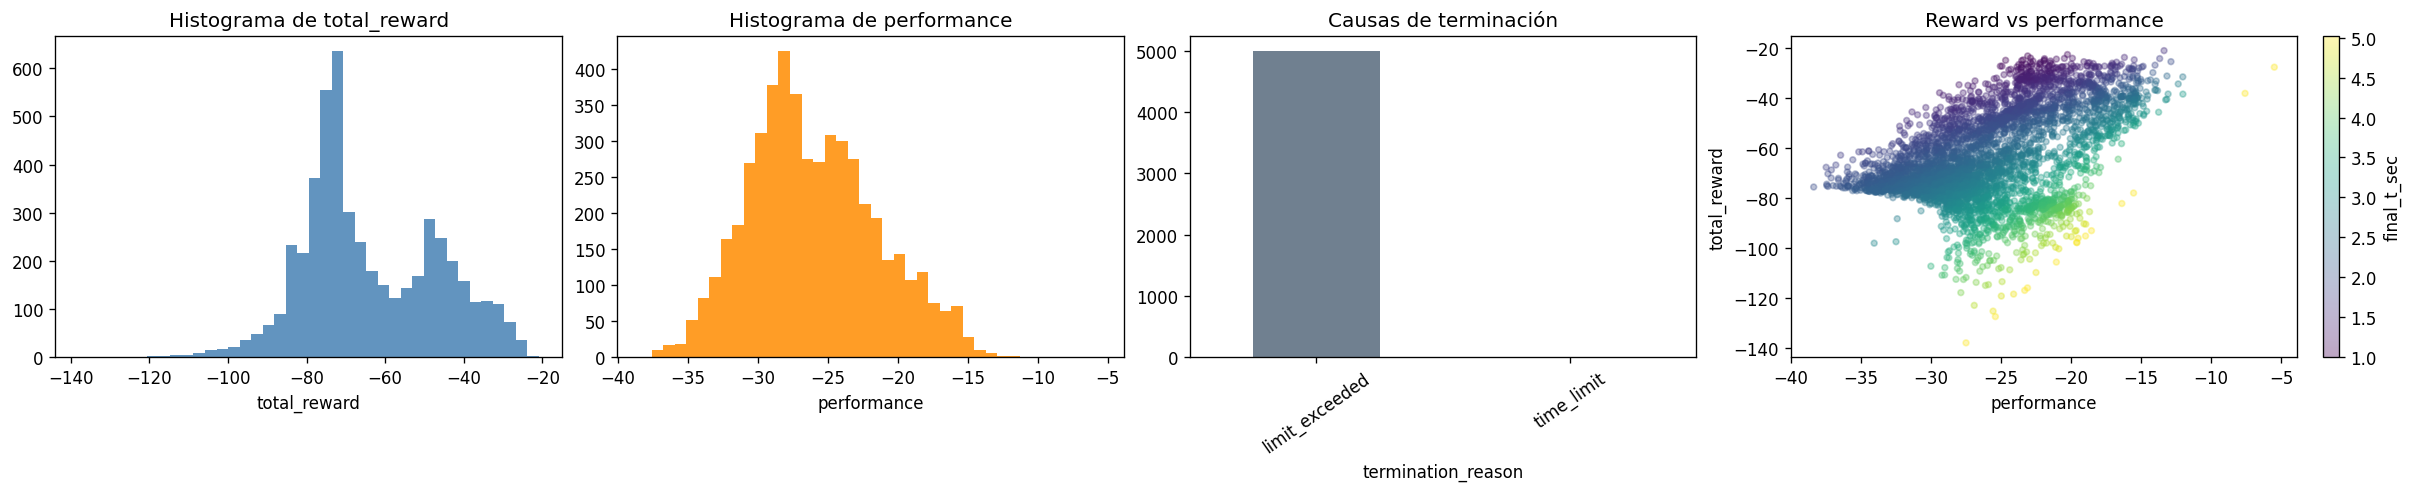

**Métricas globales**

,metric,value
0,episodes_total,5000.000000
1,stabilization_success_count,0.000000
2,stabilization_success_rate,0.000000
3,total_reward_mean,-64.061878
4,total_reward_p05,-87.900008
5,total_reward_p50,-69.342979
6,total_reward_p95,-33.151492
7,performance_mean,-25.988091
8,performance_p05,-32.894925
9,performance_p50,-26.548284


**Episodios destacados**

,selection,episode_id,total_reward,performance,final_t_sec,end_termination_reason
0,top_performance,3193,-27.528720,-5.483809,5.020,time_limit
1,top_performance,938,-38.018313,-7.573369,5.020,time_limit
2,top_performance,2631,-38.330320,-12.012009,3.191,limit_exceeded
3,top_performance,2990,-31.417214,-12.018827,2.614,limit_exceeded
4,top_performance,4054,-34.245499,-12.345169,2.774,limit_exceeded
5,top_performance,3980,-25.316696,-12.864175,1.968,limit_exceeded
6,top_performance,3989,-38.288514,-13.067752,2.930,limit_exceeded
7,top_performance,3005,-31.072293,-13.149510,2.363,limit_exceeded
8,top_performance,3018,-40.403317,-13.160690,3.070,limit_exceeded
9,top_performance,3208,-40.628807,-13.242766,3.068,limit_exceeded


In [87]:
SECTION_SUMMARY_TOP_K = 10

summary_metrics_df = pd.DataFrame(
    [
        {"metric": "episodes_total", "value": int(len(summary_df))},
        {"metric": "stabilization_success_count", "value": int((summary_df[termination_col] == "stabilization_success").sum()) if termination_col else 0},
        {"metric": "stabilization_success_rate", "value": float((summary_df[termination_col] == "stabilization_success").mean()) if termination_col else np.nan},
        {"metric": "total_reward_mean", "value": float(summary_df["total_reward"].mean())},
        {"metric": "total_reward_p05", "value": float(summary_df["total_reward"].quantile(0.05))},
        {"metric": "total_reward_p50", "value": float(summary_df["total_reward"].quantile(0.50))},
        {"metric": "total_reward_p95", "value": float(summary_df["total_reward"].quantile(0.95))},
        {"metric": "performance_mean", "value": float(summary_df["performance"].mean())},
        {"metric": "performance_p05", "value": float(summary_df["performance"].quantile(0.05))},
        {"metric": "performance_p50", "value": float(summary_df["performance"].quantile(0.50))},
        {"metric": "performance_p95", "value": float(summary_df["performance"].quantile(0.95))},
        {"metric": "final_t_sec_mean", "value": float(summary_df["final_t_sec"].mean())},
        {"metric": "final_t_sec_p95", "value": float(summary_df["final_t_sec"].quantile(0.95))},
    ]
)

top_reward_df = summary_df.nlargest(SECTION_SUMMARY_TOP_K, "total_reward")[
    ["episode_id", "total_reward", "performance", "final_t_sec", termination_col]
].copy()
top_reward_df.insert(0, "selection", "top_reward")

top_performance_df = summary_df.nlargest(SECTION_SUMMARY_TOP_K, "performance")[
    ["episode_id", "total_reward", "performance", "final_t_sec", termination_col]
].copy()
top_performance_df.insert(0, "selection", "top_performance")

highlight_episodes_df = (
    pd.concat([top_reward_df, top_performance_df], ignore_index=True)
    .drop_duplicates(subset=["selection", "episode_id"])
    .sort_values(["selection", "performance", "total_reward"], ascending=[True, False, False])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)
axes[0].hist(summary_df["total_reward"], bins=40, color="steelblue", alpha=0.85)
axes[0].set_title("Histograma de total_reward")
axes[0].set_xlabel("total_reward")

axes[1].hist(summary_df["performance"], bins=40, color="darkorange", alpha=0.85)
axes[1].set_title("Histograma de performance")
axes[1].set_xlabel("performance")

if termination_col:
    summary_df[termination_col].value_counts().sort_values(ascending=False).plot(
        kind="bar",
        ax=axes[2],
        color="slategray",
    )
axes[2].set_title("Causas de terminación")
axes[2].set_xlabel("termination_reason")
axes[2].tick_params(axis="x", rotation=35)

scatter = axes[3].scatter(
    summary_df["performance"],
    summary_df["total_reward"],
    c=summary_df["final_t_sec"],
    cmap="viridis",
    alpha=0.35,
    s=12,
)
axes[3].set_title("Reward vs performance")
axes[3].set_xlabel("performance")
axes[3].set_ylabel("total_reward")
plt.colorbar(scatter, ax=axes[3], label="final_t_sec")
plt.show()

display(Markdown("**Métricas globales**"))
display(summary_metrics_df)
display(Markdown("**Episodios destacados**"))
display(highlight_episodes_df)

export_figure(fig, ANALYSIS_SUBDIRS["summary"], "01_global_overview")
export_table(summary_metrics_df, ANALYSIS_SUBDIRS["summary"], "01_global_metrics", markdown_too=True, excel=True)
export_table(highlight_episodes_df, ANALYSIS_SUBDIRS["summary"], "02_highlight_episodes", markdown_too=True, excel=True)


## 1C. Evolución del aprendizaje

Una corrida útil no se evalúa solo por su mejor episodio. Esta sección mira tendencia, estabilidad y si el tramo final representa realmente lo mejor que la política logró descubrir.


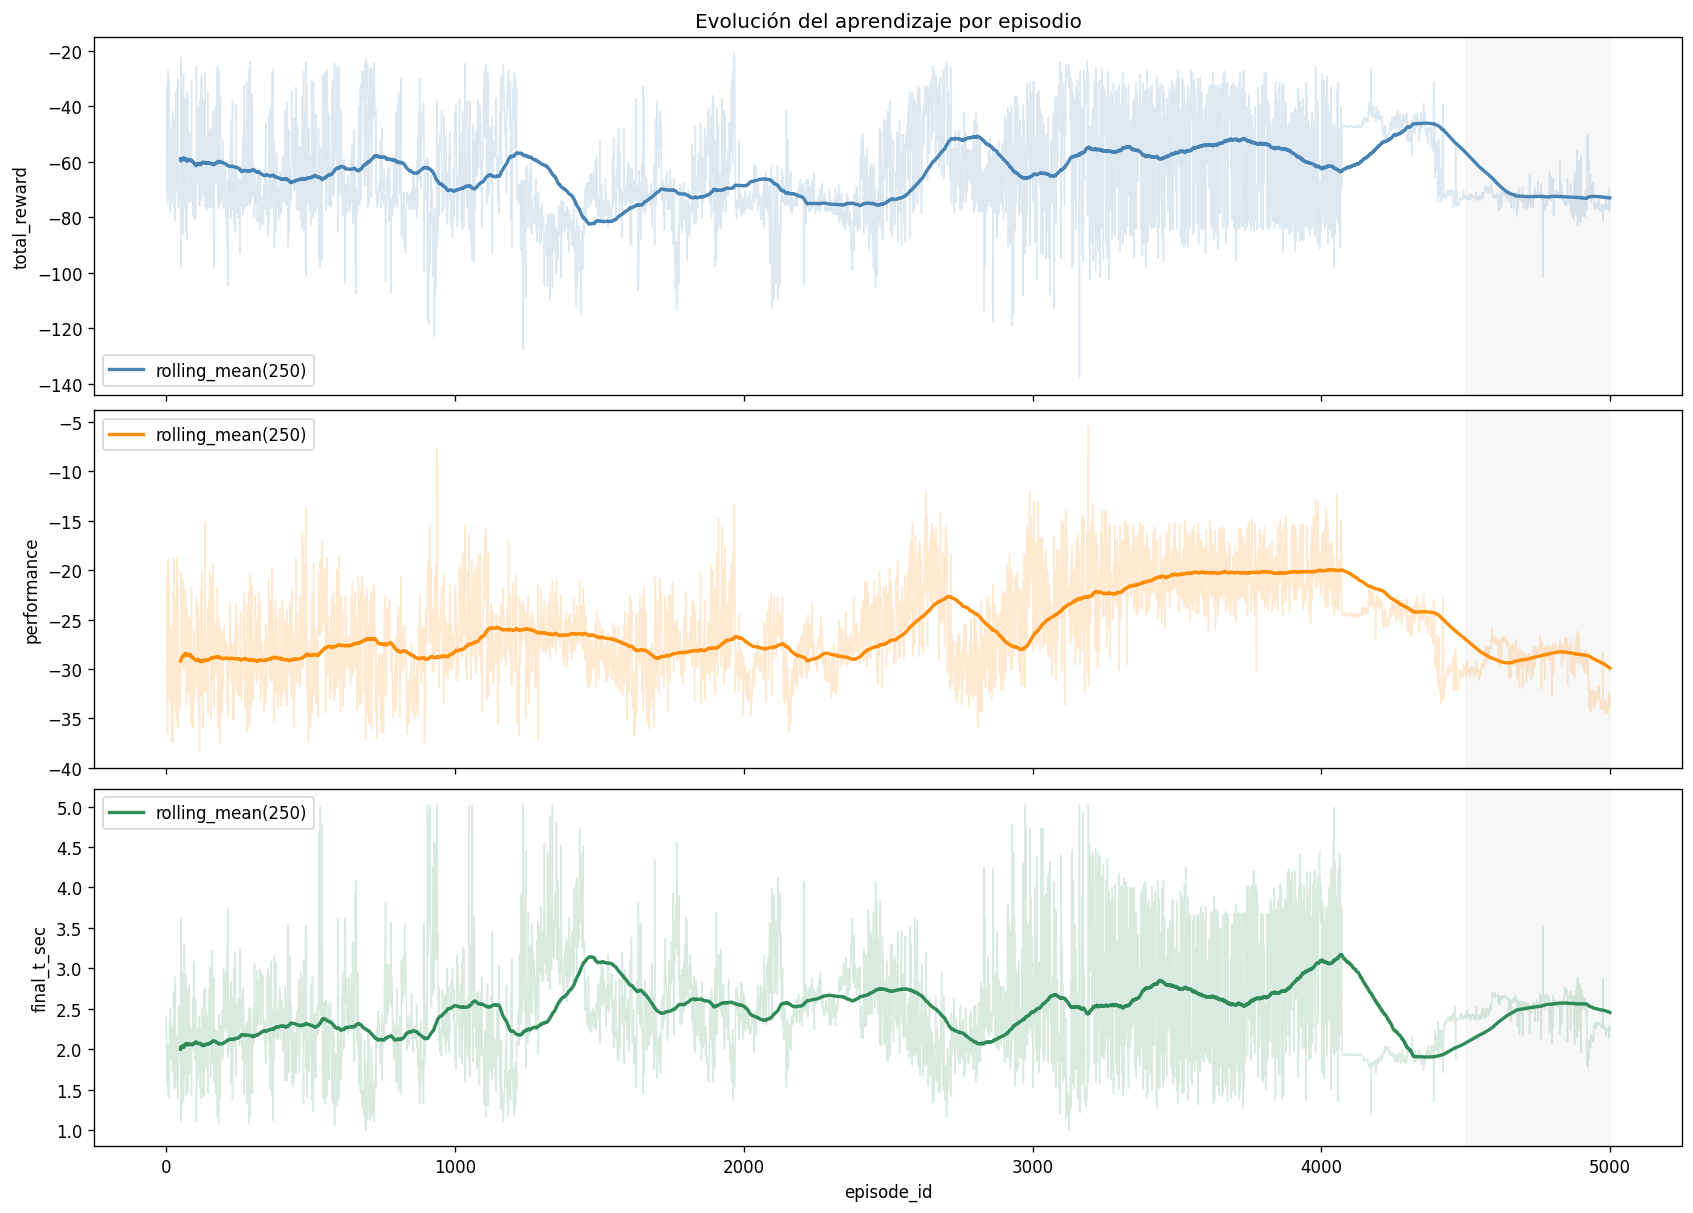

**Comparación entre ventanas**

,window,n_episodes,total_reward_mean,total_reward_p90,performance_mean,performance_p90,final_t_sec_mean,success_rate
0,first_window,500,-64.012531,-40.152426,-28.814943,-23.356548,2.217902,0.0
1,middle_window,500,-63.076602,-35.909193,-25.320975,-19.639727,2.466810,0.0
2,last_window,500,-72.761543,-69.624631,-29.323101,-27.255200,2.490262,0.0


**Top performance dentro de last_n**

,episode_id,total_reward,performance,final_t_sec,end_termination_reason
4590,4590,-69.688143,-25.858309,2.695,limit_exceeded
4885,4885,-55.916047,-26.190186,2.135,limit_exceeded
4892,4892,-64.519818,-26.464241,2.438,limit_exceeded
4591,4591,-71.359805,-26.478592,2.695,limit_exceeded
4757,4757,-71.251398,-26.606198,2.678,limit_exceeded
4630,4630,-70.574462,-26.742881,2.639,limit_exceeded
4602,4602,-72.436575,-26.758986,2.707,limit_exceeded
4595,4595,-71.608283,-26.759448,2.676,limit_exceeded
4628,4628,-70.622313,-26.771157,2.638,limit_exceeded
4633,4633,-71.162193,-26.772834,2.658,limit_exceeded


**Top performance global**

,episode_id,total_reward,performance,final_t_sec,end_termination_reason
3193,3193,-27.528720,-5.483809,5.020,time_limit
938,938,-38.018313,-7.573369,5.020,time_limit
2631,2631,-38.330320,-12.012009,3.191,limit_exceeded
2990,2990,-31.417214,-12.018827,2.614,limit_exceeded
4054,4054,-34.245499,-12.345169,2.774,limit_exceeded
3980,3980,-25.316696,-12.864175,1.968,limit_exceeded
3989,3989,-38.288514,-13.067752,2.930,limit_exceeded
3005,3005,-31.072293,-13.149510,2.363,limit_exceeded
3018,3018,-40.403317,-13.160690,3.070,limit_exceeded
3208,3208,-40.628807,-13.242766,3.068,limit_exceeded


In [88]:
SECTION_LEARNING_LAST_N = min(500, len(summary_df))
SECTION_LEARNING_ROLLING = max(50, min(250, len(summary_df) // 20))
SECTION_LEARNING_TOP_K = 10

learning_df = summary_df.sort_values("episode_id").reset_index(drop=True).copy()
for metric_col in ["total_reward", "performance", "final_t_sec"]:
    learning_df[f"{metric_col}_rolling_mean"] = learning_df[metric_col].rolling(
        SECTION_LEARNING_ROLLING,
        min_periods=max(5, SECTION_LEARNING_ROLLING // 5),
    ).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
metric_specs = [
    ("total_reward", "total_reward", "steelblue"),
    ("performance", "performance", "darkorange"),
    ("final_t_sec", "final_t_sec", "seagreen"),
]

for ax, (metric_col, label, color) in zip(axes, metric_specs):
    ax.plot(learning_df["episode_id"], learning_df[metric_col], color=color, alpha=0.18, linewidth=0.9)
    ax.plot(
        learning_df["episode_id"],
        learning_df[f"{metric_col}_rolling_mean"],
        color=color,
        linewidth=2.0,
        label=f"rolling_mean({SECTION_LEARNING_ROLLING})",
    )
    if SECTION_LEARNING_LAST_N < len(learning_df):
        start_last = int(learning_df.iloc[-SECTION_LEARNING_LAST_N]["episode_id"])
        ax.axvspan(start_last, int(learning_df["episode_id"].max()), color="lightgray", alpha=0.18)
    ax.set_ylabel(label)
    ax.legend()

axes[0].set_title("Evolución del aprendizaje por episodio")
axes[-1].set_xlabel("episode_id")
plt.show()

middle_start = max(0, len(learning_df) // 2 - SECTION_LEARNING_LAST_N // 2)
middle_end = min(len(learning_df), middle_start + SECTION_LEARNING_LAST_N)
learning_windows = {
    "first_window": learning_df.head(SECTION_LEARNING_LAST_N),
    "middle_window": learning_df.iloc[middle_start:middle_end],
    "last_window": learning_df.tail(SECTION_LEARNING_LAST_N),
}

learning_window_rows = []
for window_name, frame in learning_windows.items():
    learning_window_rows.append(
        {
            "window": window_name,
            "n_episodes": int(len(frame)),
            "total_reward_mean": float(frame["total_reward"].mean()),
            "total_reward_p90": float(frame["total_reward"].quantile(0.90)),
            "performance_mean": float(frame["performance"].mean()),
            "performance_p90": float(frame["performance"].quantile(0.90)),
            "final_t_sec_mean": float(frame["final_t_sec"].mean()),
            "success_rate": float((frame[termination_col] == "stabilization_success").mean()) if termination_col else np.nan,
        }
    )

learning_window_df = pd.DataFrame(learning_window_rows)
top_last_n_df = learning_df.tail(SECTION_LEARNING_LAST_N).nlargest(
    SECTION_LEARNING_TOP_K,
    "performance",
)[
    ["episode_id", "total_reward", "performance", "final_t_sec", termination_col]
].copy()

top_global_df = learning_df.nlargest(
    SECTION_LEARNING_TOP_K,
    "performance",
)[
    ["episode_id", "total_reward", "performance", "final_t_sec", termination_col]
].copy()

display(Markdown("**Comparación entre ventanas**"))
display(learning_window_df)
display(Markdown("**Top performance dentro de last_n**"))
display(top_last_n_df)
display(Markdown("**Top performance global**"))
display(top_global_df)

export_figure(fig, ANALYSIS_SUBDIRS["learning"], "01_learning_evolution")
export_table(learning_window_df, ANALYSIS_SUBDIRS["learning"], "02_learning_windows", markdown_too=True, excel=True)
export_table(top_last_n_df, ANALYSIS_SUBDIRS["learning"], "03_top_last_n", markdown_too=True, excel=True)
export_table(top_global_df, ANALYSIS_SUBDIRS["learning"], "04_top_global", markdown_too=True, excel=True)


## 1D. Inventario auditable de hiperparámetros

Antes de justificar ajustes conviene dejar un inventario claro de los parámetros activos, su ruta dentro de `metadata` y el rol funcional que cumplen.


In [89]:
SECTION_HP_PREFIXES = (
    "simulation.",
    "dynamic_system.termination_conditions.",
    "agent_base.",
    "reward_base.reward_calculation.principal_reward",
    "reward_base.reward_calculation.extra_rewards",
    "reward_base.reward_calculation.coordination_reward",
)

raw_hyperparameter_rows = flatten_config_scalars(config_main)
hyperparameter_inventory_df = pd.DataFrame(raw_hyperparameter_rows)
hyperparameter_inventory_df = hyperparameter_inventory_df[
    hyperparameter_inventory_df["path"].str.startswith(SECTION_HP_PREFIXES)
].copy()

hyperparameter_inventory_df["canonical_name"] = hyperparameter_inventory_df["path"].str.split(".").str[-1]
hyperparameter_inventory_df["block"] = hyperparameter_inventory_df["path"].apply(hyperparameter_block)
hyperparameter_inventory_df["role"] = hyperparameter_inventory_df["path"].apply(hyperparameter_role)
hyperparameter_inventory_df["linked_signals"] = hyperparameter_inventory_df["path"].apply(hyperparameter_signals)
hyperparameter_inventory_df = hyperparameter_inventory_df[
    ["block", "canonical_name", "path", "value", "role", "linked_signals"]
].reset_index(drop=True)

display(hyperparameter_inventory_df)
export_table(
    hyperparameter_inventory_df,
    ANALYSIS_SUBDIRS["hyperparameters"],
    "01_hyperparameter_inventory",
    excel=True,
)


,block,canonical_name,path,value,role,linked_signals
0,simulation,n_episodes,simulation.n_episodes,5000,Define la resolución temporal y la duración de...,config_only
1,simulation,episode_duration_sec,simulation.episode_duration_sec,5.0,Define la resolución temporal y la duración de...,config_only
2,simulation,dt_sec,simulation.dt_sec,0.001,Define la resolución temporal y la duración de...,config_only
3,simulation,decision_interval_sec,simulation.decision_interval_sec,0.02,Define la resolución temporal y la duración de...,config_only
4,termination,cart_position,dynamic_system.termination_conditions.boundary...,"[-5.0, 5.0]","Define criterios de éxito, estabilidad y termi...",cart_position
...,...,...,...,...,...,...
189,coordination_reward,contribution_effort_signal,reward_base.reward_calculation.coordination_re...,u_eff_{var_obj},Parámetro activo sin descripción heurística es...,"u_eff, progress, u_total"
190,coordination_reward,pendulum_angle,reward_base.reward_calculation.coordination_re...,1.0,Parámetro activo sin descripción heurística es...,"pendulum_angle, u_eff, progress, u_total"
191,coordination_reward,cart_position,reward_base.reward_calculation.coordination_re...,1.0,Parámetro activo sin descripción heurística es...,"cart_position, u_eff, progress, u_total"
192,coordination_reward,epsilon_credit,reward_base.reward_calculation.coordination_re...,0.000001,Regula reparto de crédito cuando las contribuc...,"u_eff, progress, u_total"


## 1E. Ganancias PID aprendidas

Aquí se observa si las ganancias finales propuestas por la política convergen, siguen dispersas o se apoyan en regiones extremas para producir los mejores episodios.


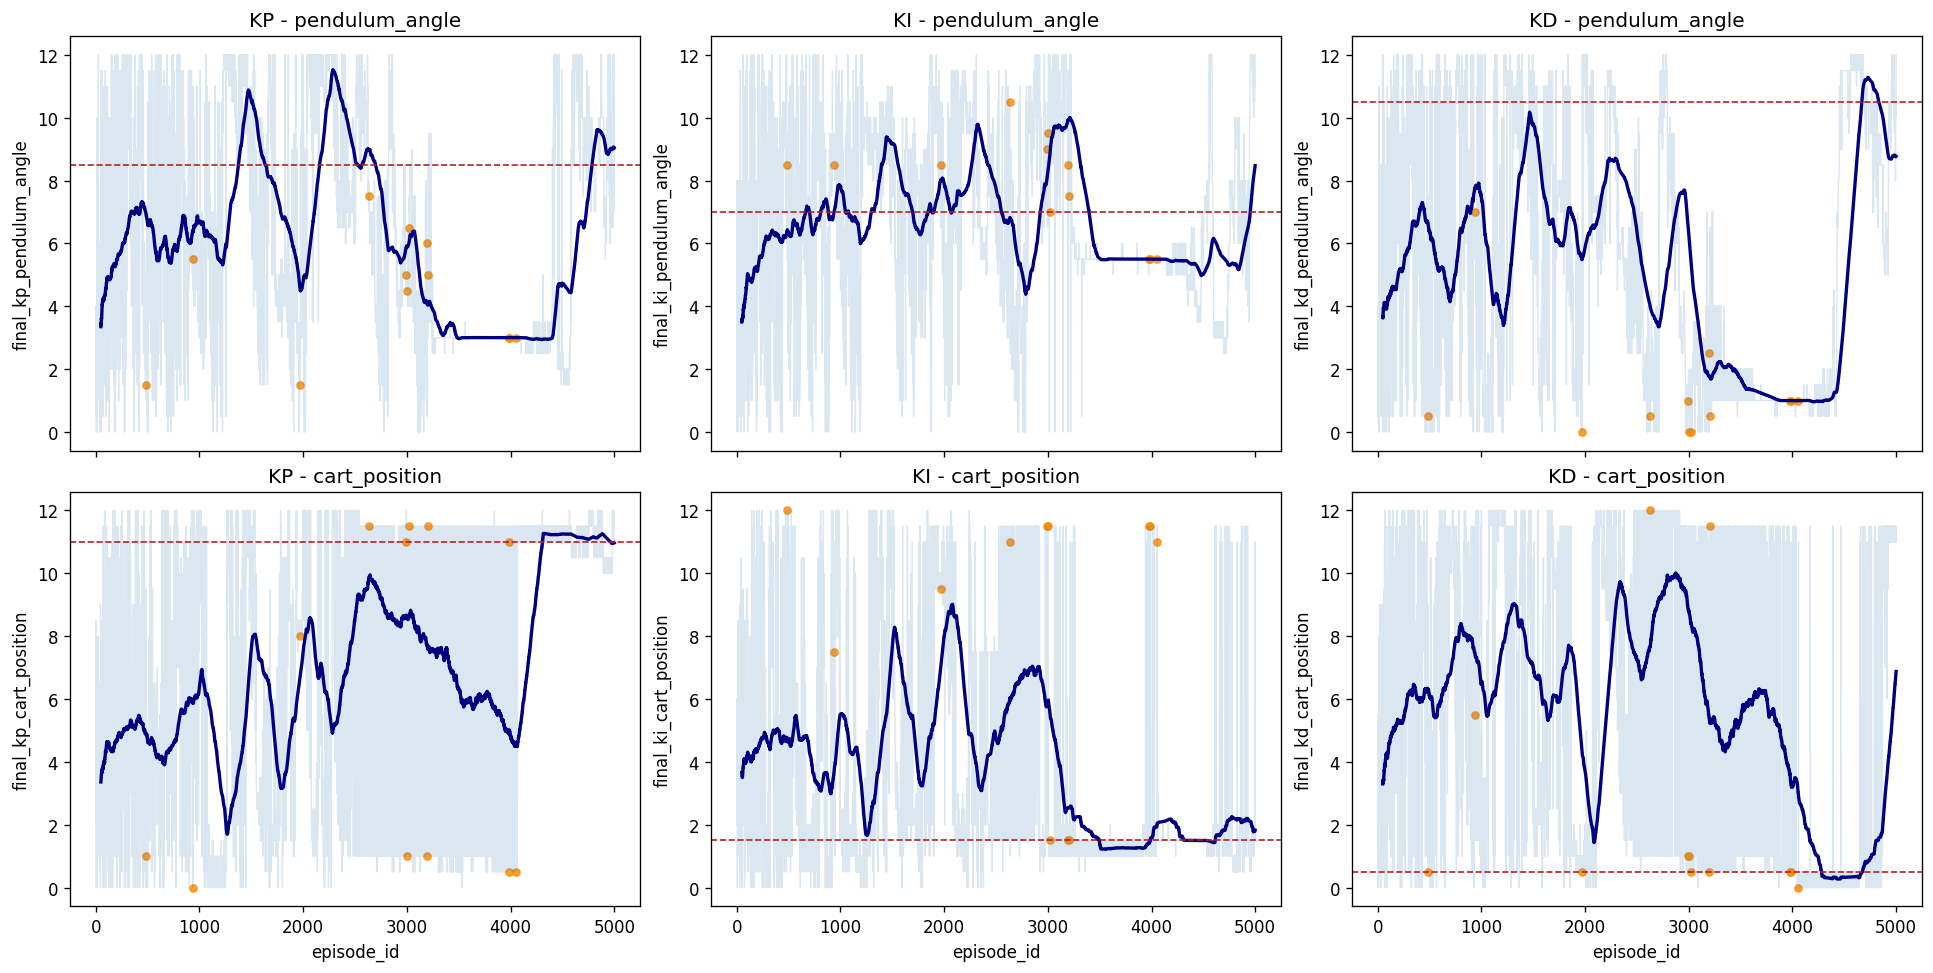

,var_obj,gain,global_mean,global_std,last_n_mean,last_n_std,top_performance_median,global_p10,global_p50,global_p90
0,pendulum_angle,kp,6.1905,3.565123,8.255,3.160134,4.75,2.5,5.0,11.5
1,pendulum_angle,ki,6.7910,2.853077,6.898,2.891594,8.50,3.0,6.0,10.5
2,pendulum_angle,kd,5.2914,4.040056,9.980,1.909947,0.75,1.0,4.5,11.0
3,cart_position,kp,7.0626,4.504191,11.027,0.524711,4.50,1.0,9.0,11.5
4,cart_position,ki,3.7768,3.725568,1.983,2.431262,11.00,1.0,1.5,11.0
5,cart_position,kd,5.6240,4.825752,3.891,4.980787,0.50,0.5,4.5,11.5


In [90]:
SECTION_PID_LAST_N = min(500, len(summary_df))
SECTION_PID_TOP_K = 12

pid_fig, pid_axes = plt.subplots(
    len(target_var_objs),
    3,
    figsize=(16, 4 * len(target_var_objs)),
    sharex=True,
    constrained_layout=True,
)
if len(target_var_objs) == 1:
    pid_axes = np.array([pid_axes])

pid_summary_rows = []
top_perf_ids = set(summary_df.nlargest(SECTION_PID_TOP_K, "performance")["episode_id"].astype(int).tolist())
last_window_df = summary_df.tail(SECTION_PID_LAST_N)

for row_idx, var_obj in enumerate(target_var_objs):
    for col_idx, gain_name in enumerate(["kp", "ki", "kd"]):
        col_name = f"final_{gain_name}_{var_obj}"
        ax = pid_axes[row_idx, col_idx]

        if col_name not in summary_df.columns:
            ax.set_axis_off()
            continue

        ax.plot(summary_df["episode_id"], summary_df[col_name], color="steelblue", alpha=0.20, linewidth=0.8)
        ax.plot(
            summary_df["episode_id"],
            summary_df[col_name].rolling(SECTION_LEARNING_ROLLING, min_periods=max(5, SECTION_LEARNING_ROLLING // 5)).mean(),
            color="navy",
            linewidth=2.0,
        )

        highlight_df = summary_df[summary_df["episode_id"].isin(top_perf_ids)]
        ax.scatter(highlight_df["episode_id"], highlight_df[col_name], color="darkorange", s=18, alpha=0.80)
        ax.axhline(last_window_df[col_name].median(), color="firebrick", linestyle="--", linewidth=1.0)
        ax.set_title(f"{gain_name.upper()} - {var_obj}")
        ax.set_ylabel(col_name)

        pid_summary_rows.append(
            {
                "var_obj": var_obj,
                "gain": gain_name,
                "global_mean": float(summary_df[col_name].mean()),
                "global_std": float(summary_df[col_name].std()),
                "last_n_mean": float(last_window_df[col_name].mean()),
                "last_n_std": float(last_window_df[col_name].std()),
                "top_performance_median": float(highlight_df[col_name].median()),
                "global_p10": float(summary_df[col_name].quantile(0.10)),
                "global_p50": float(summary_df[col_name].quantile(0.50)),
                "global_p90": float(summary_df[col_name].quantile(0.90)),
            }
        )

pid_axes[-1, 0].set_xlabel("episode_id")
pid_axes[-1, 1].set_xlabel("episode_id")
pid_axes[-1, 2].set_xlabel("episode_id")
plt.show()

pid_gain_summary_df = pd.DataFrame(pid_summary_rows)
display(pid_gain_summary_df)

export_figure(pid_fig, ANALYSIS_SUBDIRS["summary"], "03_pid_gains")
export_table(pid_gain_summary_df, ANALYSIS_SUBDIRS["summary"], "03_pid_gain_summary", excel=True)


## 1F. Causas de fallo y restricciones físicas

El objetivo es separar si el cuello de botella dominante está en la terminación, en la excursión física o en la duración útil alcanzada por la política.


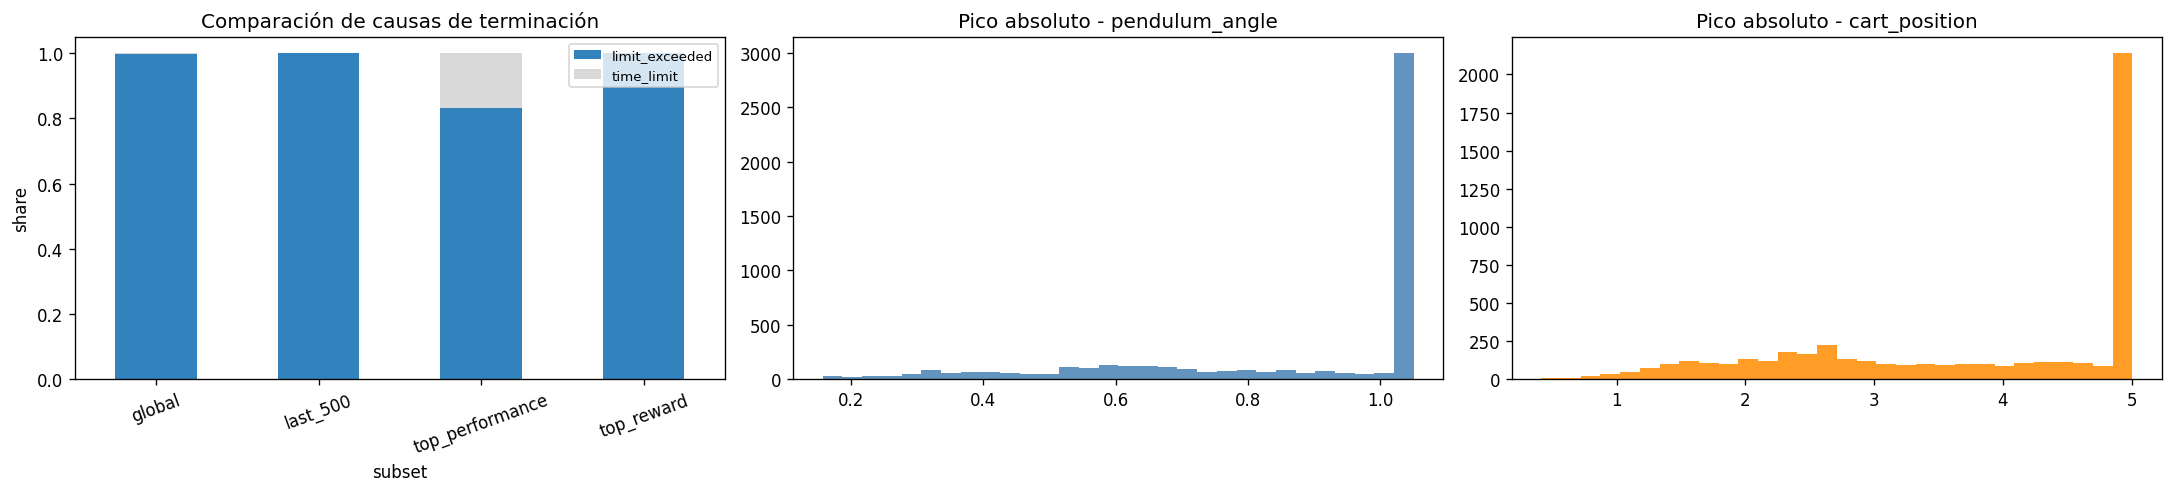

**Resumen físico de excursiones**

,var_obj,peak_mean,peak_p50,peak_p90,peak_min,peak_max
0,pendulum_angle,0.879639,1.047519,1.048981,0.157012,1.050892
1,cart_position,3.784074,4.311733,5.003723,0.413513,5.006344


**Comparación de terminaciones por subconjunto**

,subset,termination_reason,share,count
0,global,limit_exceeded,0.997800,4989
1,global,time_limit,0.002200,11
2,last_500,limit_exceeded,1.000000,500
3,top_reward,limit_exceeded,1.000000,12
4,top_performance,limit_exceeded,0.833333,10
5,top_performance,time_limit,0.166667,2


In [91]:
SECTION_FAILURE_LAST_N = min(500, len(summary_df))
SECTION_FAILURE_TOP_K = 12

failure_df = summary_df.copy()
for var_obj in target_var_objs:
    failure_df[f"abs_peak_{var_obj}"] = absolute_peak_from_summary(failure_df, f"{var_obj}_raw")

subset_map = {
    "global": failure_df,
    f"last_{SECTION_FAILURE_LAST_N}": failure_df.tail(SECTION_FAILURE_LAST_N),
    "top_reward": failure_df.nlargest(SECTION_FAILURE_TOP_K, "total_reward"),
    "top_performance": failure_df.nlargest(SECTION_FAILURE_TOP_K, "performance"),
}

termination_compare_rows = []
if termination_col:
    for subset_name, subset_df in subset_map.items():
        shares = subset_df[termination_col].value_counts(normalize=True)
        for reason, share in shares.items():
            termination_compare_rows.append(
                {
                    "subset": subset_name,
                    "termination_reason": reason,
                    "share": float(share),
                    "count": int((subset_df[termination_col] == reason).sum()),
                }
            )

termination_compare_df = pd.DataFrame(termination_compare_rows)
peak_summary_rows = []
for var_obj in target_var_objs:
    peak_col = f"abs_peak_{var_obj}"
    peak_summary_rows.append(
        {
            "var_obj": var_obj,
            "peak_mean": float(failure_df[peak_col].mean()),
            "peak_p50": float(failure_df[peak_col].quantile(0.50)),
            "peak_p90": float(failure_df[peak_col].quantile(0.90)),
            "peak_min": float(failure_df[peak_col].min()),
            "peak_max": float(failure_df[peak_col].max()),
        }
    )

physical_peak_summary_df = pd.DataFrame(peak_summary_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
if not termination_compare_df.empty:
    pivot = termination_compare_df.pivot(index="subset", columns="termination_reason", values="share").fillna(0.0)
    pivot.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20c")
    axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Comparación de causas de terminación")
axes[0].set_ylabel("share")
axes[0].tick_params(axis="x", rotation=20)

if len(target_var_objs) >= 1:
    axes[1].hist(failure_df[f"abs_peak_{target_var_objs[0]}"], bins=30, color="steelblue", alpha=0.85)
    axes[1].set_title(f"Pico absoluto - {target_var_objs[0]}")

if len(target_var_objs) >= 2:
    axes[2].hist(failure_df[f"abs_peak_{target_var_objs[1]}"], bins=30, color="darkorange", alpha=0.85)
    axes[2].set_title(f"Pico absoluto - {target_var_objs[1]}")
else:
    axes[2].axis("off")

plt.show()

display(Markdown("**Resumen físico de excursiones**"))
display(physical_peak_summary_df)
if not termination_compare_df.empty:
    display(Markdown("**Comparación de terminaciones por subconjunto**"))
    display(termination_compare_df)

export_figure(fig, ANALYSIS_SUBDIRS["summary"], "04_failure_modes_and_peaks")
export_table(physical_peak_summary_df, ANALYSIS_SUBDIRS["summary"], "04_physical_peak_summary", excel=True)
if not termination_compare_df.empty:
    export_table(termination_compare_df, ANALYSIS_SUBDIRS["summary"], "05_termination_comparison", excel=True)


## 1G. Selección estructurada de episodios

En lugar de depender solo del mejor episodio global, esta sección construye un conjunto de referencias útiles para revisar la corrida desde perspectivas distintas.


In [92]:
SECTION_EPISODE_TOP_K = 8

episode_selection_rows = []

def register_episode_selection(label, frame):
    local = frame.copy()
    local = local[["episode_id", "total_reward", "performance", "final_t_sec", termination_col]].copy()
    local["selection_label"] = label
    local["selection_rank"] = np.arange(1, len(local) + 1)
    episode_selection_rows.extend(local.to_dict(orient="records"))

register_episode_selection("top_reward", summary_df.nlargest(SECTION_EPISODE_TOP_K, "total_reward"))
register_episode_selection("top_performance", summary_df.nlargest(SECTION_EPISODE_TOP_K, "performance"))

success_source_df = summary_df[summary_df[termination_col] == "stabilization_success"] if termination_col else pd.DataFrame()
if len(success_source_df) > 0:
    register_episode_selection(
        "top_stability",
        success_source_df.nlargest(SECTION_EPISODE_TOP_K, ["final_t_sec", "performance"]),
    )
else:
    register_episode_selection(
        "top_stability_proxy",
        summary_df.nlargest(SECTION_EPISODE_TOP_K, ["final_t_sec", "performance"]),
    )

angle_peak_col = f"abs_peak_{target_var_objs[0]}"
register_episode_selection(
    "best_angle_peak",
    failure_df.nsmallest(SECTION_EPISODE_TOP_K, angle_peak_col),
)

if len(target_var_objs) >= 2:
    cart_peak_col = f"abs_peak_{target_var_objs[1]}"
    register_episode_selection(
        "best_cart_return",
        failure_df.nsmallest(SECTION_EPISODE_TOP_K, cart_peak_col),
    )

failure_only_df = failure_df[failure_df[termination_col] != "stabilization_success"] if termination_col else failure_df
register_episode_selection(
    "representative_early_failure",
    failure_only_df.nsmallest(min(5, SECTION_EPISODE_TOP_K), "final_t_sec"),
)

raw_episode_selection_df = pd.DataFrame(episode_selection_rows)
selected_episodes_df = (
    raw_episode_selection_df.groupby("episode_id", as_index=False)
    .agg(
        {
            "total_reward": "max",
            "performance": "max",
            "final_t_sec": "max",
            termination_col: "first",
            "selection_label": lambda values: " | ".join(sorted(set(values))),
            "selection_rank": "min",
        }
    )
    .sort_values(["selection_rank", "performance", "total_reward"], ascending=[True, False, False])
    .reset_index(drop=True)
)

display(selected_episodes_df)
export_table(selected_episodes_df, ANALYSIS_SUBDIRS["episodes"], "01_selected_episodes", markdown_too=True, excel=True)


,episode_id,total_reward,performance,final_t_sec,end_termination_reason,selection_label,selection_rank
0,3193,-27.528720,-5.483809,5.020,time_limit,top_performance | top_stability_proxy,1
1,1967,-20.890975,-13.357401,1.564,limit_exceeded,top_reward,1
2,692,-23.024527,-23.093808,0.997,limit_exceeded,best_cart_return | representative_early_failur...,1
3,1244,-108.750091,-24.372499,4.462,limit_exceeded,best_angle_peak,1
4,938,-38.018313,-7.573369,5.020,time_limit,top_performance | top_stability_proxy,2
5,51,-22.458340,-20.250983,1.109,limit_exceeded,best_cart_return | top_reward,2
6,689,-23.872589,-22.888388,1.043,limit_exceeded,best_cart_return | representative_early_failur...,2
7,1754,-81.026226,-23.472256,3.452,limit_exceeded,best_angle_peak,2
8,3126,-24.768305,-24.669627,1.004,limit_exceeded,best_cart_return | representative_early_failure,2
9,2631,-38.330320,-12.012009,3.191,limit_exceeded,top_performance,3


## 2. Superficies teóricas de la reward principal y de la reward proxy por lazo

Esta sección caracteriza la geometría del incentivo **antes** de mirar el comportamiento real del episodio.  
La primera fila muestra la reward principal aislada en el espacio error-derivada.  
La segunda fila aproxima la reward total por lazo sumando reward principal, bonus de banda y penalty condicional.

La utilidad de esta sección es mostrar el paisaje que la política recibe como señal potencial de aprendizaje.


In [93]:
# ----------------------------
# Input de la sección 2
# ----------------------------

SECTION_2_TARGET_VARS = target_var_objs
SECTION_2_ERROR_POINTS = 240
SECTION_2_DERIVATIVE_POINTS = 240
SECTION_2_CONTROL_POINTS = 240
SECTION_2_EDOT_LEVEL_FOR_PROXY = 0.0


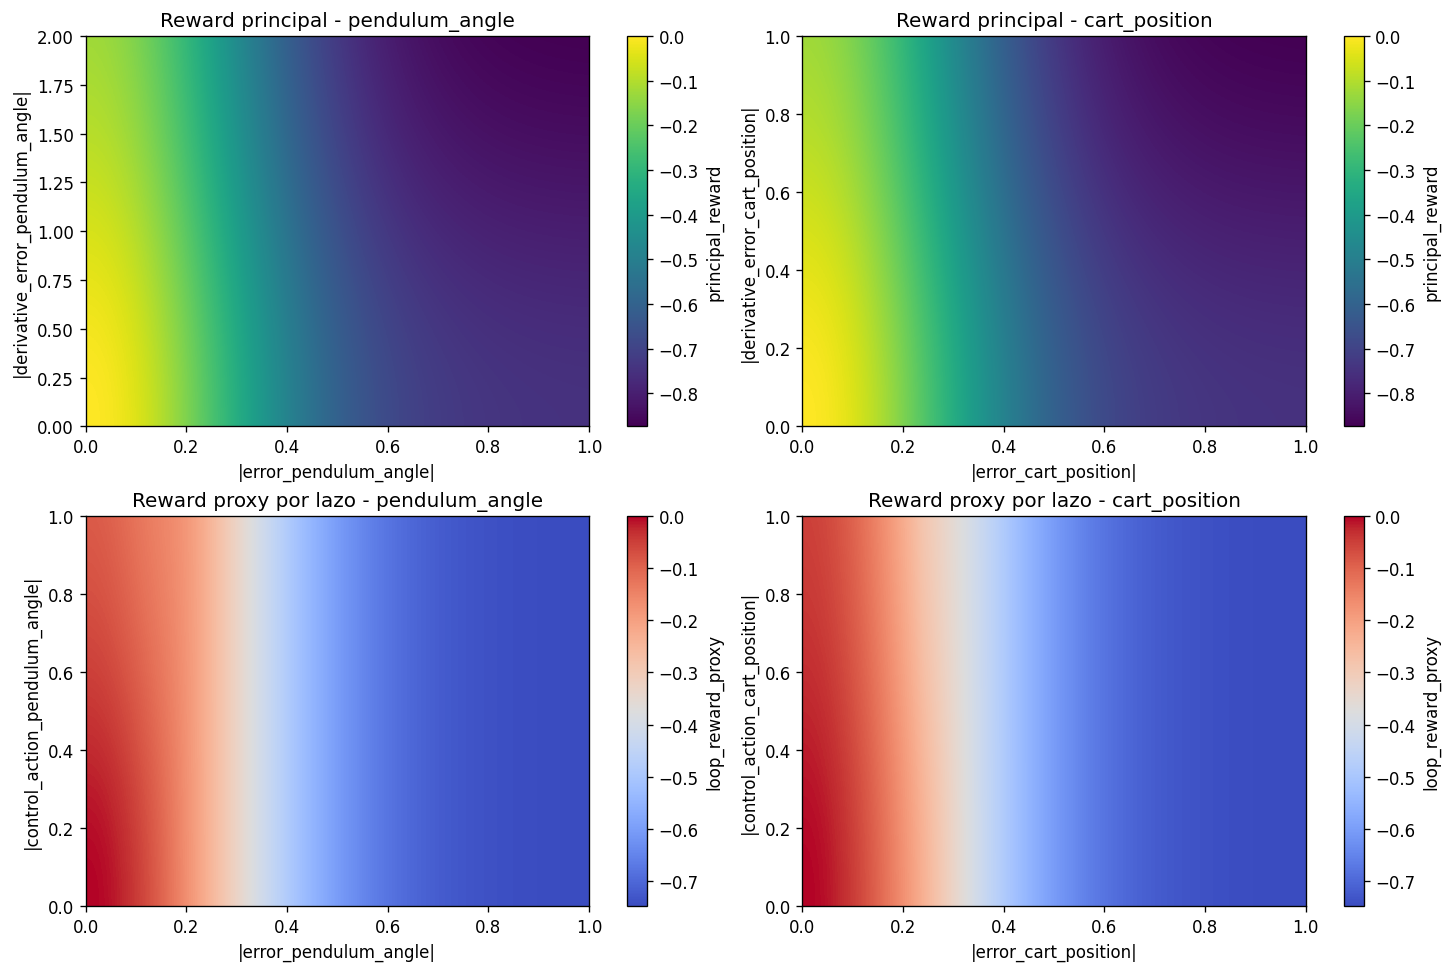

In [94]:
# ----------------------------
# Superficies teóricas
# ----------------------------

fig, axes = plt.subplots(2, len(SECTION_2_TARGET_VARS), figsize=(6 * len(SECTION_2_TARGET_VARS), 8), constrained_layout=True)
if len(SECTION_2_TARGET_VARS) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col, var_obj in enumerate(SECTION_2_TARGET_VARS):
    meta = variable_catalog_df[variable_catalog_df["var_obj"] == var_obj].iloc[0]
    error_max = metric_range_abs(normalization_cfg, var_obj, "e", fallback=1.0)
    derivative_max = metric_range_abs(normalization_cfg, var_obj, "edot", fallback=1.0)
    control_max = metric_range_abs(normalization_cfg, var_obj, "u", fallback=1.0)

    error_axis = np.linspace(0.0, error_max, SECTION_2_ERROR_POINTS)
    derivative_axis = np.linspace(0.0, derivative_max, SECTION_2_DERIVATIVE_POINTS)
    control_axis = np.linspace(0.0, control_max, SECTION_2_CONTROL_POINTS)

    grid_error, grid_derivative = np.meshgrid(error_axis, derivative_axis)
    principal_surface = principal_loop_reward(
        principal_cfg=principal_cfg,
        normalization_cfg=normalization_cfg,
        principal_features=principal_features,
        var_obj=var_obj,
        error_level=grid_error,
        edot_level=grid_derivative,
    )

    image_1 = axes[0, col].imshow(
        principal_surface,
        extent=[error_axis.min(), error_axis.max(), derivative_axis.min(), derivative_axis.max()],
        origin="lower",
        aspect="auto",
        cmap="viridis",
    )
    axes[0, col].set_title(f"Reward principal - {var_obj}")
    axes[0, col].set_xlabel(f"|{meta['error_col']}|")
    axes[0, col].set_ylabel(f"|{meta['derivative_error_col']}|")
    plt.colorbar(image_1, ax=axes[0, col], label="principal_reward")

    proxy_error, proxy_control = np.meshgrid(error_axis, control_axis)
    total_surface = total_loop_proxy(
        config_main=config_main,
        principal_cfg=principal_cfg,
        normalization_cfg=normalization_cfg,
        principal_features=principal_features,
        extra_cfg=extra_cfg,
        decision_steps=decision_steps,
        var_obj=var_obj,
        error_level=proxy_error,
        control_level=proxy_control,
        edot_level=SECTION_2_EDOT_LEVEL_FOR_PROXY,
    )

    image_2 = axes[1, col].imshow(
        total_surface,
        extent=[error_axis.min(), error_axis.max(), control_axis.min(), control_axis.max()],
        origin="lower",
        aspect="auto",
        cmap="coolwarm",
    )
    if band_cfg["enabled"] is True:
        band_low, band_high = band_range(config_main, band_cfg, var_obj)
        axes[1, col].axvspan(0.0, max(abs(band_low), abs(band_high)), alpha=0.12, color="cyan")
    axes[1, col].set_title(f"Reward proxy por lazo - {var_obj}")
    axes[1, col].set_xlabel(f"|{meta['error_col']}|")
    axes[1, col].set_ylabel(f"|{meta['control_action_col']}|")
    plt.colorbar(image_2, ax=axes[1, col], label="loop_reward_proxy")

plt.show()

export_figure(fig, ANALYSIS_SUBDIRS["reward_behavior"], "01_theoretical_surfaces")


### Interpretación de la sección 2

La fila superior representa la **reward principal aislada**.  
Allí el observador debe concentrarse en la forma de la región favorable alrededor del origen. Si el valor más atractivo se concentra en una zona demasiado estrecha, la política puede pasar mucho tiempo recibiendo una señal pobre aun cuando el sistema ya se esté acercando a la estabilización. En cambio, si esa región es demasiado amplia y plana, la reward puede perder poder discriminativo y dejar de diferenciar entre un estado razonable y un estado realmente bueno.

La lectura conjunta de error y derivada permite responder una pregunta importante: **cómo castiga la reward la combinación de desvío y velocidad de corrección**.  
En control adaptativo, esa lectura es más informativa que mirar solo el error. Una superficie bien construida no debería premiar de forma equivalente un error pequeño con alta velocidad residual y un error pequeño con dinámica ya amortiguada.

La fila inferior aproxima la **reward total por lazo**.  
Esta figura deja ver cómo cambia la geometría cuando se suman shaping accesorios. Aquí interesa observar si el bonus de banda y los penalties condicionales refuerzan la intención principal o si, por el contrario, la deforman. Una señal de deformación aparece cuando la reward se vuelve atractiva en regiones que implican demasiado esfuerzo de control o demasiado error respecto de la banda operativa deseada.

La franja sombreada sirve como referencia de operación deseada.  
No necesariamente coincide con el máximo global del mapa, pero sí debería estar contenida en una zona claramente favorable. Cuando la banda útil queda fuera de la región de mejor reward, la arquitectura del incentivo empieza a empujar en dirección distinta a la estabilización que se quiere consolidar.

Esta sección no confirma todavía si la política aprendió bien o mal.  
Lo que sí permite es evaluar si la geometría diseñada **tiene sentido antes de contrastarla con la experiencia observada**.


## 3. Cortes teóricos de la reward

Las superficies muestran estructura global.  
Los cortes muestran sensibilidad. Esta sección transforma la geometría anterior en curvas comparables que permiten ver con claridad qué parámetro domina la caída de la reward.


In [95]:
# ----------------------------
# Input de la sección 3
# ----------------------------

SECTION_3_TARGET_VARS = target_var_objs
SECTION_3_ERROR_LEVELS_MODE = "band_based"
SECTION_3_CONTROL_LEVELS = [0.0, 0.15, 0.35, 0.65]   # proporciones del máximo de control observado


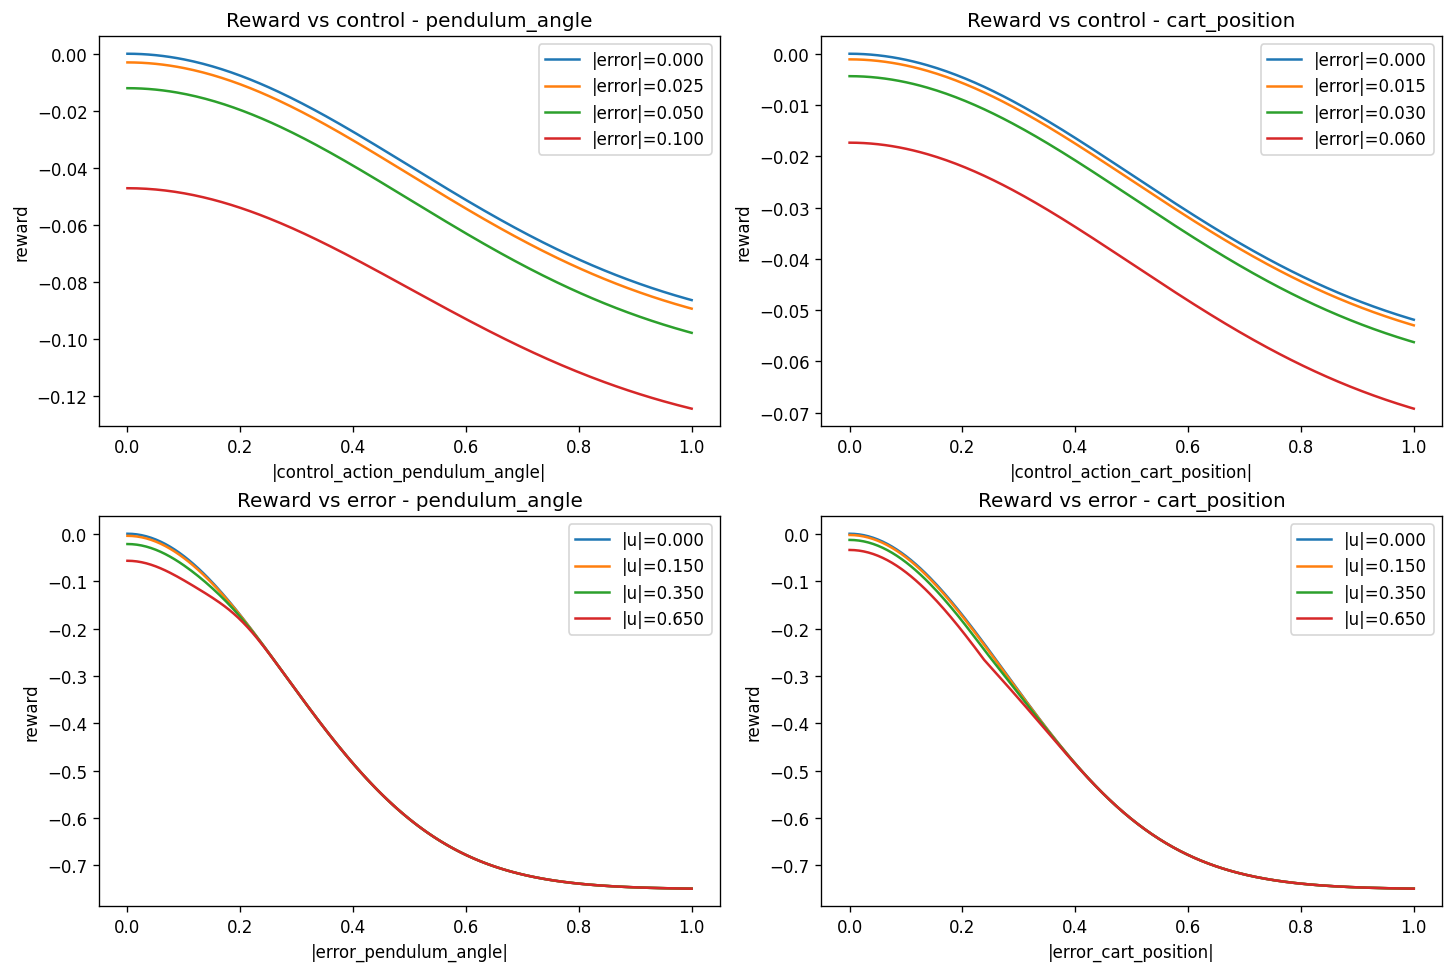

In [96]:
# ----------------------------
# Cortes teóricos de reward
# ----------------------------

fig, axes = plt.subplots(2, len(SECTION_3_TARGET_VARS), figsize=(6 * len(SECTION_3_TARGET_VARS), 8), constrained_layout=True)
if len(SECTION_3_TARGET_VARS) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col, var_obj in enumerate(SECTION_3_TARGET_VARS):
    meta = variable_catalog_df[variable_catalog_df["var_obj"] == var_obj].iloc[0]
    error_max = metric_range_abs(normalization_cfg, var_obj, "e", fallback=1.0)
    control_max = metric_range_abs(normalization_cfg, var_obj, "u", fallback=1.0)

    error_axis = np.linspace(0.0, error_max, 240)
    control_axis = np.linspace(0.0, control_max, 240)

    band_low, band_high = band_range(config_main, band_cfg, var_obj)
    band_limit = max(abs(band_low), abs(band_high))
    error_levels = [0.0, 0.5 * band_limit, band_limit, min(error_max, 2.0 * band_limit)]

    for error_level in error_levels:
        curve = total_loop_proxy(
            config_main=config_main,
            principal_cfg=principal_cfg,
            normalization_cfg=normalization_cfg,
            principal_features=principal_features,
            extra_cfg=extra_cfg,
            decision_steps=decision_steps,
            var_obj=var_obj,
            error_level=error_level,
            control_level=control_axis,
            edot_level=0.0,
        )
        axes[0, col].plot(control_axis, curve, label=f"|error|={error_level:.3f}")
    axes[0, col].set_title(f"Reward vs control - {var_obj}")
    axes[0, col].set_xlabel(f"|{meta['control_action_col']}|")
    axes[0, col].set_ylabel("reward")
    axes[0, col].legend()

    for ratio in SECTION_3_CONTROL_LEVELS:
        control_level = ratio * control_max
        curve = total_loop_proxy(
            config_main=config_main,
            principal_cfg=principal_cfg,
            normalization_cfg=normalization_cfg,
            principal_features=principal_features,
            extra_cfg=extra_cfg,
            decision_steps=decision_steps,
            var_obj=var_obj,
            error_level=error_axis,
            control_level=control_level,
            edot_level=0.0,
        )
        axes[1, col].plot(error_axis, curve, label=f"|u|={control_level:.3f}")
    if band_cfg["enabled"] is True:
        axes[1, col].axvspan(0.0, band_limit, alpha=0.15, color="lightsteelblue")
    axes[1, col].set_title(f"Reward vs error - {var_obj}")
    axes[1, col].set_xlabel(f"|{meta['error_col']}|")
    axes[1, col].set_ylabel("reward")
    axes[1, col].legend()

plt.show()

export_figure(fig, ANALYSIS_SUBDIRS["reward_behavior"], "02_theoretical_cuts")


### Interpretación de la sección 3

La fila superior responde a una pregunta directa: **cuánto castiga la reward el aumento del control cuando el error se mantiene en distintos niveles de referencia**.  
Esta lectura permite distinguir entre una reward que tolera esfuerzo correctivo razonable y una reward que comienza a castigar demasiado pronto. Cuando la caída de la curva es muy abrupta incluso con errores todavía relevantes, la política puede verse empujada a reducir acción antes de haber consolidado la corrección del estado.

La fila inferior invierte la lógica: **cómo cambia la reward cuando el error crece, manteniendo congelado el nivel de control**.  
Esta vista deja ver si el incentivo conserva pendiente suficiente para seguir atrayendo al sistema hacia la banda de interés. Si la reward fuera de banda sigue siendo relativamente alta, entonces el gradiente disponible para empujar hacia la zona útil puede ser demasiado débil.

La franja sombreada vuelve a marcar la banda operativa deseada.  
La lectura importante aquí no es solo si la curva alcanza su mejor valor cerca de esa banda, sino también qué ocurre justo antes y justo después de ella. Una reward útil suele tener transición clara: debería resultar visiblemente mejor permanecer dentro de banda que operar con desvíos que ya comprometen la estabilización.

Estas curvas son especialmente valiosas para tuning porque transforman una intuición visual en una decisión paramétrica.  
Si la caída frente al control es demasiado severa, normalmente conviene revisar penalties o pesos asociados al esfuerzo. Si la curva frente al error es demasiado plana, suele ser señal de que el peso o la sensibilidad del error están subescalados.

En otras palabras, esta sección permite decidir **si el siguiente ajuste debe ensanchar la zona atractiva, reforzar la selectividad o suavizar el castigo por esfuerzo**.


## 4. Cartografía teórica del bloque coordinativo

La coordinación no debe leerse como un bonus accesorio sin estructura.  
Este bloque tiene una geometría propia: potencial de tarea, progreso premiable y reparto de crédito entre lazos.

La función de esta sección es mostrar esa geometría antes de confrontarla con la corrida observada.


In [97]:
# ----------------------------
# Input de la sección 4
# ----------------------------

SECTION_4_TARGET_VARS = target_var_objs
SECTION_4_PHI_POINTS = 220
SECTION_4_PROGRESS_MIN = -0.35
SECTION_4_PROGRESS_MAX = 0.35
SECTION_4_OTHER_RAW_CONTRIBUTION = 0.10
SECTION_4_PROGRESS_LEVEL_FOR_REWARD = 0.10


KeyError: 'L_edot'

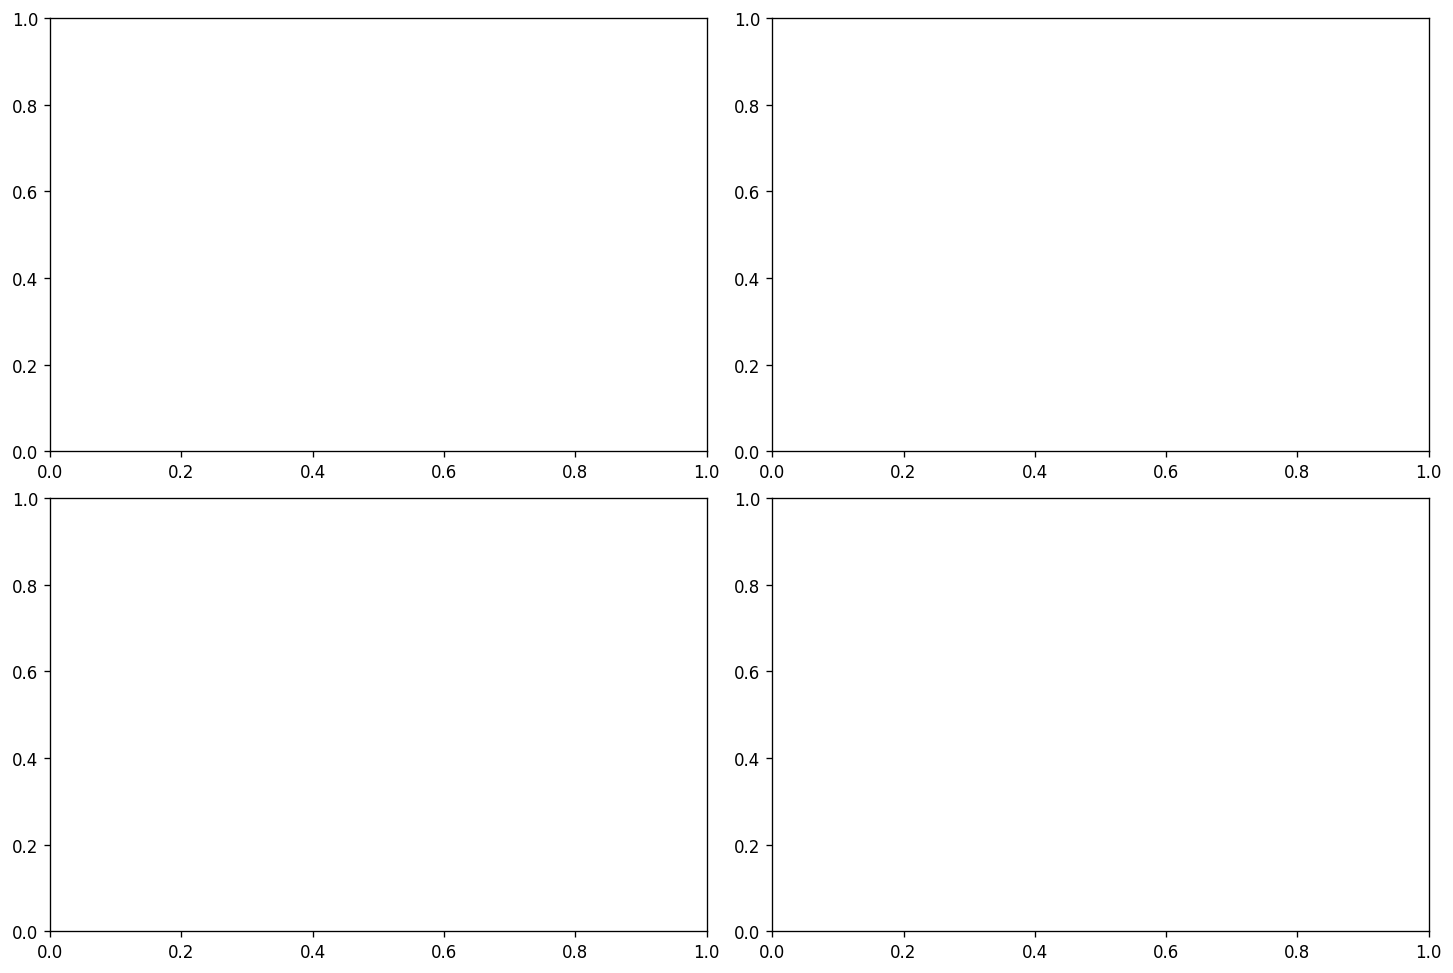

In [98]:
# ----------------------------
# Cartografía teórica de coordinación
# ----------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# 1) Mapas de potencial parcial por lazo
selected_var = SECTION_4_TARGET_VARS[0]
phi_axis = np.linspace(0.0, 1.0, SECTION_4_PHI_POINTS)
grid_e, grid_edot = np.meshgrid(phi_axis, phi_axis)
partial_phi = coordination_partial_potential_map(coord_cfg, grid_e, grid_edot, selected_var)

img = axes[0, 0].imshow(
    partial_phi,
    extent=[phi_axis.min(), phi_axis.max(), phi_axis.min(), phi_axis.max()],
    origin="lower",
    aspect="auto",
    cmap="viridis",
)
axes[0, 0].set_title(f"Potencial parcial Phi - {selected_var}")
axes[0, 0].set_xlabel(f"L_e_{selected_var}")
axes[0, 0].set_ylabel(f"L_edot_{selected_var}")
plt.colorbar(img, ax=axes[0, 0], label="partial_phi")

# 2) Progreso premiable
delta_phi_axis = np.linspace(SECTION_4_PROGRESS_MIN, SECTION_4_PROGRESS_MAX, 400)
rewardable_progress = coordination_progress_rewardable(coord_cfg, delta_phi_axis)
axes[0, 1].plot(delta_phi_axis, rewardable_progress)
axes[0, 1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0, 1].axhline(coord_cfg["progress_clip_max"], color="tab:red", linestyle="--", linewidth=1)
axes[0, 1].set_title("Progreso premiable")
axes[0, 1].set_xlabel("Delta Phi")
axes[0, 1].set_ylabel("progress_rewardable")

# 3) Fracción de crédito
raw_axis = np.linspace(0.0, 0.4, 400)
for var_obj in SECTION_4_TARGET_VARS:
    share_curve = coordination_credit_share(raw_axis, SECTION_4_OTHER_RAW_CONTRIBUTION, coord_cfg["epsilon_credit"])
    axes[1, 0].plot(raw_axis, share_curve, label=var_obj)
axes[1, 0].set_title("Fracción de crédito por lazo")
axes[1, 0].set_xlabel("raw_credit propio")
axes[1, 0].set_ylabel("credit_share")
axes[1, 0].legend()

# 4) Bonus coordinativo final
for share_level in [0.1, 0.25, 0.5, 0.75, 1.0]:
    reward_curve = coordination_reward_curve(coord_cfg["global_weight"], rewardable_progress, share_level)
    axes[1, 1].plot(delta_phi_axis, reward_curve, label=f"credit_share={share_level:.2f}")
axes[1, 1].set_title("Bonus coordinativo final")
axes[1, 1].set_xlabel("Delta Phi")
axes[1, 1].set_ylabel("coordination_reward")
axes[1, 1].legend()

plt.show()

coord_overview_df = pd.DataFrame([{
    "reward_name": coord_cfg["reward_name"],
    "global_weight": coord_cfg["global_weight"],
    "progress_positive_only": coord_cfg["progress_positive_only"],
    "progress_clip_max": coord_cfg["progress_clip_max"],
    "epsilon_credit": coord_cfg["epsilon_credit"],
    "credit_reduction_mode": coord_cfg["credit_reduction_mode"],
}])

coord_weights_rows = []
for feature_name, weight_map in coord_cfg["potential_weights"].items():
    for var_obj, weight_value in weight_map.items():
        coord_weights_rows.append({
            "feature": feature_name,
            "var_obj": var_obj,
            "weight": weight_value,
        })
coord_weights_df = pd.DataFrame(coord_weights_rows)

display(Markdown("**Parámetros globales del bloque coordinativo**"))
display(coord_overview_df)

display(Markdown("**Pesos del potencial de tarea**"))
display(coord_weights_df)

export_figure(fig, ANALYSIS_SUBDIRS["reward_behavior"], "03_coordination_maps")


### Interpretación de la sección 4

El mapa de potencial parcial muestra cómo cada lazo aporta al valor de tarea que luego se compara entre intervalos.  
Cuando las pendientes de este mapa son muy pequeñas, el potencial cambia poco aunque el sistema mejore, y eso reduce la capacidad del bloque coordinativo para registrar progreso útil. Cuando las pendientes son demasiado grandes, pequeñas variaciones de las métricas pueden traducirse en saltos exagerados de potencial, haciendo que la coordinación se vuelva demasiado sensible.

La curva de **progreso premiable** es la lectura más importante de la parte global del bloque.  
Aquí se ve con claridad si el diseño solo recompensa mejoras positivas, si castiga retrocesos o si corta el efecto máximo demasiado pronto. En el caso actual, la lógica positiva con clip superior implica que la coordinación actúa más como refuerzo por avance que como castigo por deterioro. Esa decisión afecta directamente el papel numérico del bloque dentro de la reward total.

La curva de **fracción de crédito** no controla el tamaño total del bonus por sí sola; controla sobre todo su reparto.  
Por eso esta figura debe leerse como una regla de atribución. Si un lazo incrementa mucho su contribución correctiva mientras el resto permanece modesto, su participación en el bonus sube. Si varios lazos muestran aportes comparables, el premio se reparte de manera más pareja. En este punto conviene recordar que un reparto equilibrado no significa necesariamente un bonus grande; para eso también debe existir progreso de tarea.

La figura del **bonus coordinativo final** une las dos piezas anteriores.  
Se observa cuánto reward efectivo puede emerger para distintos niveles de fracción de crédito a medida que aumenta el progreso. Esta figura ayuda a responder una pregunta práctica: si el bloque coordinativo parece demasiado pequeño en la corrida observada, la causa puede estar en el `global_weight`, en el clip de progreso, en la debilidad del potencial o en la ausencia de crédito correctivo visible.

Las tablas inferiores convierten la lectura visual en contrato paramétrico.  
Allí se identifica qué features alimentan el potencial y qué peso tiene cada lazo. Esta revisión es importante porque el bloque coordinativo no opera sobre estados físicos directos, sino sobre métricas ya procesadas. En consecuencia, un peso alto sobre una métrica de baja variación observada puede terminar aportando menos de lo esperado.

Esta sección deja lista la pregunta para el bloque empírico: **si esta geometría teórica existe, cuánto de ella apareció realmente en la corrida seleccionada**.


## 5. Curvas reales del episodio seleccionado

Ahora el análisis deja la teoría y entra en la evidencia observada.  
La meta de esta sección es reconstruir la señal de aprendizaje que efectivamente recibió el sistema en el episodio de referencia.


In [99]:
# ----------------------------
# Input de la sección 5
# ----------------------------

SECTION_5_TARGET_VARS = target_var_objs
SECTION_5_ROLLING_WINDOW = ROLLING_WINDOW


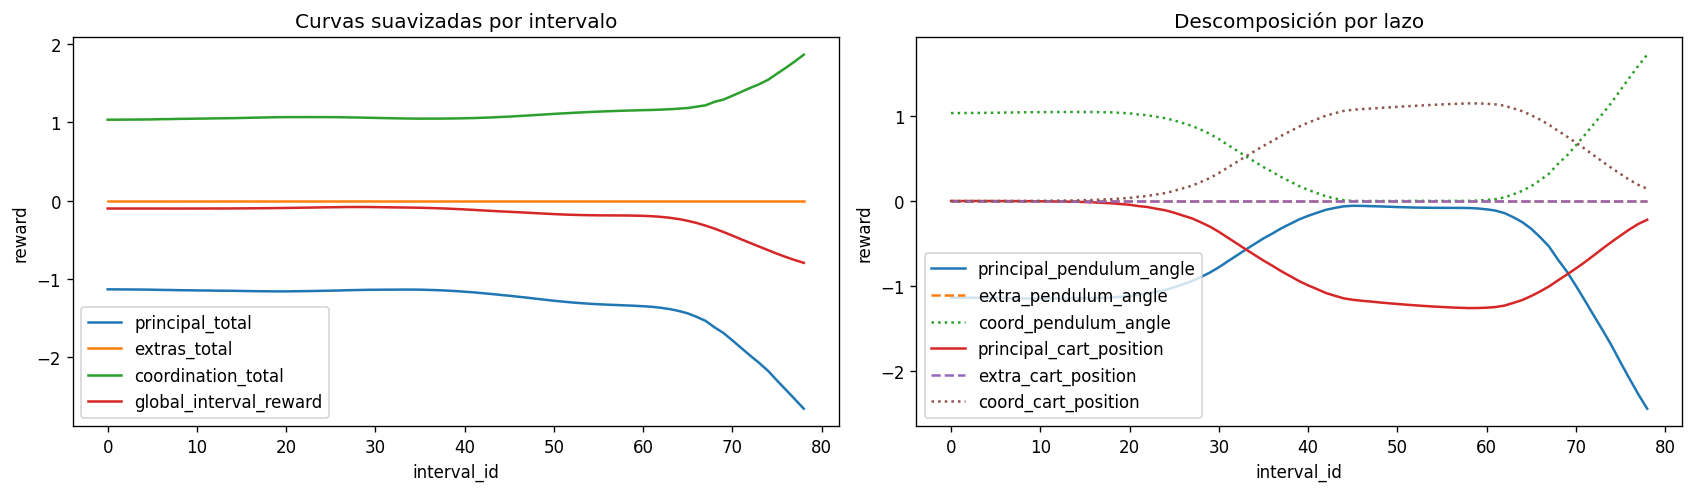

,interval_id,global_interval_reward,principal_total_rebuilt,extra_total_rebuilt,coordination_total_rebuilt,principal_loop_pendulum_angle,extra_total_pendulum_angle,coordination_total_pendulum_angle,assigned_reward_pendulum_angle,principal_loop_cart_position,extra_total_cart_position,coordination_total_cart_position,assigned_reward_cart_position
0,0.0,-0.101955,-1.136033,0.0,1.034078,-1.136029,0.0,1.034077,-0.101952,-0.000004,0.0,0.000001,-0.000003
1,1.0,-0.102009,-1.137080,0.0,1.035071,-1.137010,0.0,1.035032,-0.101978,-0.000070,0.0,0.000038,-0.000031
2,2.0,-0.102096,-1.138655,0.0,1.036559,-1.138498,0.0,1.036471,-0.102027,-0.000157,0.0,0.000089,-0.000069
3,3.0,-0.102260,-1.140770,0.0,1.038510,-1.140132,0.0,1.038057,-0.102075,-0.000638,0.0,0.000453,-0.000185
4,4.0,-0.102351,-1.143246,0.0,1.040896,-1.142486,0.0,1.040382,-0.102104,-0.000760,0.0,0.000514,-0.000247
5,5.0,-0.102581,-1.146332,0.0,1.043751,-1.144113,0.0,1.042049,-0.102064,-0.002219,0.0,0.001702,-0.000517
6,6.0,-0.102516,-1.160694,0.0,1.058177,-1.158781,0.0,1.056885,-0.101896,-0.001913,0.0,0.001293,-0.000620
7,7.0,-0.102605,-1.153159,0.0,1.050554,-1.147497,0.0,1.046110,-0.101387,-0.005662,0.0,0.004444,-0.001218
8,8.0,-0.101944,-1.167291,0.0,1.065347,-1.162833,0.0,1.062213,-0.100620,-0.004458,0.0,0.003134,-0.001324
9,9.0,-0.101264,-1.155324,0.0,1.054060,-1.147721,0.0,1.048302,-0.099419,-0.007603,0.0,0.005758,-0.001845


In [100]:
# ----------------------------
# Curvas reales del episodio
# ----------------------------

behavior_df = build_behavior_df(interval_df, step_df, variable_catalog_df)
step_reward_df = build_step_reward_df_from_episode(selected_episode, variable_catalog_df)

plot_df = behavior_df.copy()
plot_df["principal_total_smooth"] = plot_df["principal_total_rebuilt"].rolling(SECTION_5_ROLLING_WINDOW, min_periods=1).mean()
plot_df["extra_total_smooth"] = plot_df["extra_total_rebuilt"].rolling(SECTION_5_ROLLING_WINDOW, min_periods=1).mean()
plot_df["coordination_total_smooth"] = plot_df["coordination_total_rebuilt"].rolling(SECTION_5_ROLLING_WINDOW, min_periods=1).mean()
plot_df["global_reward_smooth"] = plot_df["global_interval_reward"].rolling(SECTION_5_ROLLING_WINDOW, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

axes[0].plot(plot_df["interval_id"], plot_df["principal_total_smooth"], label="principal_total")
axes[0].plot(plot_df["interval_id"], plot_df["extra_total_smooth"], label="extras_total")
axes[0].plot(plot_df["interval_id"], plot_df["coordination_total_smooth"], label="coordination_total")
axes[0].plot(plot_df["interval_id"], plot_df["global_reward_smooth"], label="global_interval_reward")
axes[0].set_title("Curvas suavizadas por intervalo")
axes[0].set_xlabel("interval_id")
axes[0].set_ylabel("reward")
axes[0].legend()

for var_obj in SECTION_5_TARGET_VARS:
    axes[1].plot(plot_df["interval_id"], plot_df[f"principal_loop_{var_obj}"].rolling(SECTION_5_ROLLING_WINDOW, min_periods=1).mean(), label=f"principal_{var_obj}")
    axes[1].plot(plot_df["interval_id"], plot_df[f"extra_total_{var_obj}"].rolling(SECTION_5_ROLLING_WINDOW, min_periods=1).mean(), linestyle="--", label=f"extra_{var_obj}")
    axes[1].plot(plot_df["interval_id"], plot_df[f"coordination_total_{var_obj}"].rolling(SECTION_5_ROLLING_WINDOW, min_periods=1).mean(), linestyle=":", label=f"coord_{var_obj}")
axes[1].set_title("Descomposición por lazo")
axes[1].set_xlabel("interval_id")
axes[1].set_ylabel("reward")
axes[1].legend()

plt.show()

display_cols = ["interval_id", "global_interval_reward", "principal_total_rebuilt", "extra_total_rebuilt", "coordination_total_rebuilt"]
for var_obj in SECTION_5_TARGET_VARS:
    display_cols += [f"principal_loop_{var_obj}", f"extra_total_{var_obj}", f"coordination_total_{var_obj}", f"assigned_reward_{var_obj}"]

display(behavior_df[display_cols].head(-20))

export_figure(fig, ANALYSIS_SUBDIRS["reward_behavior"], "04_selected_episode_reward_curves")
export_table(behavior_df, ANALYSIS_SUBDIRS["reward_behavior"], "04_behavior_interval", excel=True)
export_table(step_reward_df, ANALYSIS_SUBDIRS["reward_behavior"], "04_step_reward_detail", excel=False)


### Interpretación de la sección 5

La gráfica izquierda separa la reward total en sus bloques globales: principal, extras, coordinación y reward final observada.  
Esta vista sirve para entender qué componente está gobernando la señal de aprendizaje a lo largo del episodio. Si la reward global sigue casi exactamente a la principal, entonces el shaping accesorio tiene rol marginal. Si, por el contrario, la global se explica sobre todo por extras o coordinación, el aprendizaje puede depender excesivamente de piezas complementarias.

La gráfica derecha baja la lectura al nivel de cada lazo.  
Aquí interesa comparar la escala relativa de `principal_loop`, `extra_total` y `coordination_total`. Esta descomposición es especialmente útil cuando un lazo parece aprender mejor que otro: la diferencia no siempre proviene de la dinámica física; también puede surgir de cómo fue compuesta la señal de reward que recibió cada uno.

La tabla inferior convierte la figura en evidencia auditable.  
Cada fila resume un intervalo y muestra la composición reconstruida de la reward. Conviene revisar si la suma de principal, extras y coordinación se acerca a la reward asignada esperada. Cuando aparecen discrepancias persistentes, normalmente no es un problema gráfico, sino una señal de que conviene revisar el modo de asignación de reward o la forma en que el notebook está separando componentes.

Esta sección permite responder una pregunta central de diseño: **qué bloque sostuvo realmente el aprendizaje en el episodio seleccionado**.  
Si el desempeño bueno coincide con una principal fuerte, el diseño base está cumpliendo su función. Si el desempeño bueno aparece solo cuando intervienen extras o coordinación, entonces el siguiente tuning debe preguntarse si esas ayudas están reforzando bien la base o si están compensando una base insuficiente.

La lectura correcta no consiste en decidir que un extra grande es “bueno” o “malo” por sí mismo.  
Lo importante es evaluar si su magnitud es coherente con el papel que se esperaba de él dentro de la arquitectura total de reward.


## 6. Perfiles cruzados

Esta sección conserva el valor de los gráficos del notebook anterior, pero ahora insertados en un relato de diseño.  
Su función es mostrar cómo cambia la reward observada cuando una variable física se recorre a lo largo del eje X, condicionando la lectura por distintos niveles de otra señal relevante.


In [101]:
# ----------------------------
# Input de la sección 6
# ----------------------------

SECTION_6_TARGET_VARS = target_var_objs
SECTION_6_PROFILE_SPECS = [
    {
        "target_var": target_var_objs[0],
        "slice_var": target_var_objs[1] if len(target_var_objs) > 1 else target_var_objs[0],
    },
    {
        "target_var": target_var_objs[1] if len(target_var_objs) > 1 else target_var_objs[0],
        "slice_var": target_var_objs[0],
    },
]
SECTION_6_SLICE_VALUES = None
SECTION_6_REWARD_COL = "global_reward_per_step"


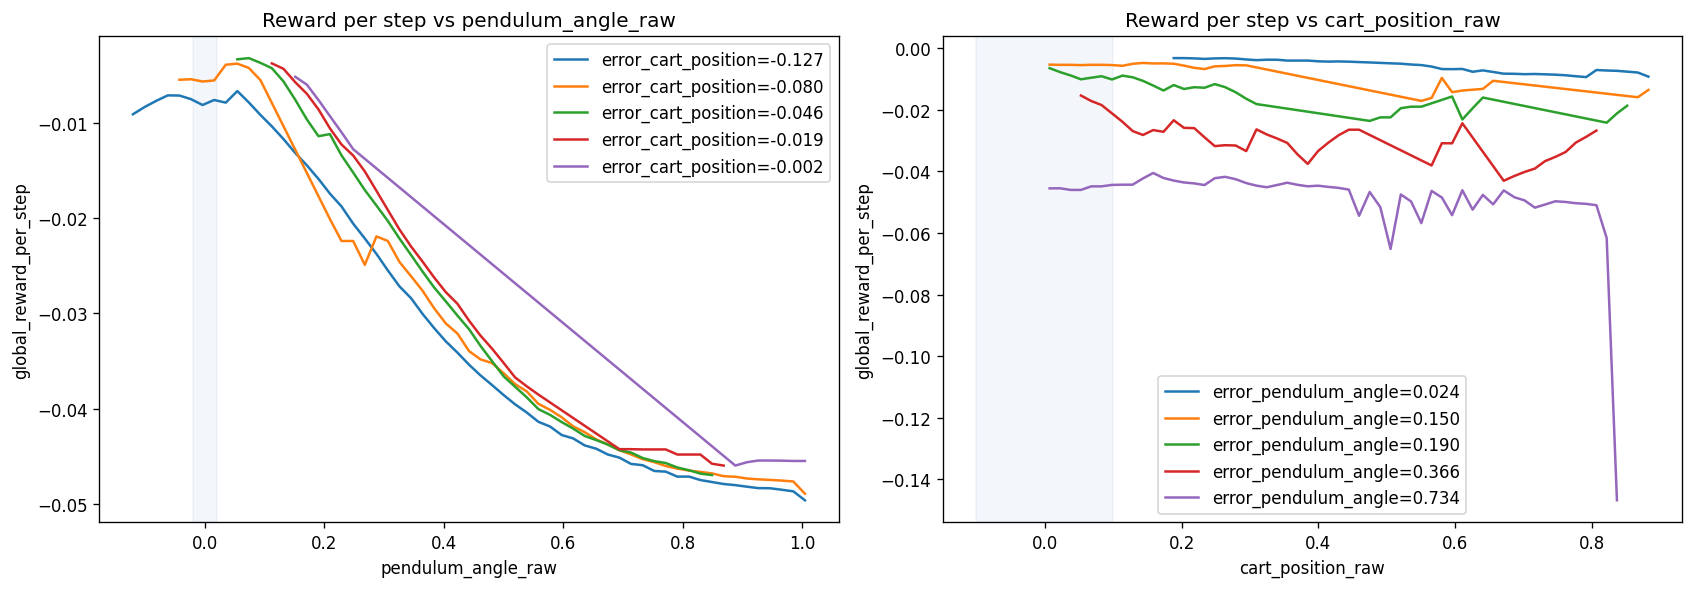

**Soporte empírico — Reward per step vs pendulum_angle_raw**

,target_var,slice_label,slice_value,slice_low,slice_high,n_points,x_min,x_max
0,pendulum_angle,error_cart_position,-0.126737,-0.180445,-0.105002,3317,-0.143858,1.046979
1,pendulum_angle,error_cart_position,-0.079781,-0.105002,-0.063084,2658,-0.042274,1.046646
2,pendulum_angle,error_cart_position,-0.046365,-0.063084,-0.031203,2988,0.051561,0.859765
3,pendulum_angle,error_cart_position,-0.019461,-0.031203,-0.009422,2802,0.107310,0.869257
4,pendulum_angle,error_cart_position,-0.001983,-0.009422,0.004212,3437,0.144667,1.044200


**Soporte empírico — Reward per step vs cart_position_raw**

,target_var,slice_label,slice_value,slice_low,slice_high,n_points,x_min,x_max
0,cart_position,error_pendulum_angle,0.024271,-0.137373,0.091381,2545,0.000000e+00,0.902223
1,cart_position,error_pendulum_angle,0.149926,0.091381,0.161727,4303,1.479248e-07,0.888161
2,cart_position,error_pendulum_angle,0.190253,0.161727,0.254172,2749,4.322710e-03,0.858792
3,cart_position,error_pendulum_angle,0.366376,0.254172,0.526236,2765,5.782493e-02,0.813246
4,cart_position,error_pendulum_angle,0.733684,0.526236,0.997267,2840,-2.210518e-02,0.839060


In [102]:
# ----------------------------
# Construcción y gráficos de perfiles cruzados
# ----------------------------

cross_profile_df = build_cross_profile_df(
    run_dir=RUN_DIR,
    summary_df=summary_df,
    selected_episode_id=selected_episode_id,
    variable_catalog=variable_catalog_df,
    mode=CROSS_PROFILE_SCOPE,
    top_k=CROSS_PROFILE_TOP_K,
)

fig, axes = plt.subplots(1, len(SECTION_6_PROFILE_SPECS), figsize=(7 * len(SECTION_6_PROFILE_SPECS), 4.8), constrained_layout=True)
if len(SECTION_6_PROFILE_SPECS) == 1:
    axes = [axes]

section_6_support_tables = {}

for ax, spec in zip(axes, SECTION_6_PROFILE_SPECS):
    target_var = spec["target_var"]
    slice_var = spec["slice_var"]

    target_meta = variable_catalog_df[variable_catalog_df["var_obj"] == target_var].iloc[0]
    slice_meta = variable_catalog_df[variable_catalog_df["var_obj"] == slice_var].iloc[0]

    title = f"Reward per step vs {target_meta['raw_state_col']}"
    x_label = target_meta["raw_state_col"]
    slice_label = slice_meta["error_col"]

    section_6_support_tables[title] = plot_cross_reward_profiles(
        ax=ax,
        frame=cross_profile_df,
        x_col=target_meta["raw_state_col"],
        slice_col=slice_meta["error_col"],
        reward_col=SECTION_6_REWARD_COL,
        target_var=target_var,
        slice_label=slice_label,
        title=title,
        x_label=x_label,
        stabilization_band=target_meta["stabilization_band_raw"],
        slice_values=SECTION_6_SLICE_VALUES,
        x_bins=CROSS_PROFILE_X_BINS,
        min_curve_points=CROSS_PROFILE_MIN_CURVE_POINTS,
    )

plt.show()

for title, support_df in section_6_support_tables.items():
    display(Markdown(f"**Soporte empírico — {title}**"))
    display(support_df)

export_figure(fig, ANALYSIS_SUBDIRS["reward_behavior"], "05_cross_profiles")
export_table(cross_profile_df, ANALYSIS_SUBDIRS["reward_behavior"], "05_cross_profile_points", excel=False)
for support_title, support_df in section_6_support_tables.items():
    export_table(
        support_df,
        ANALYSIS_SUBDIRS["reward_behavior"],
        f"05_support_{slugify(support_title)}",
        excel=False,
    )


### Interpretación de la sección 6

Cada curva de esta sección debe leerse como una **lectura condicional de la reward**.  
No se está observando simplemente la relación entre una variable física y el reward, sino cómo esa relación cambia cuando otra señal relevante se encuentra en distintos regímenes. Esa es la razón por la cual estos perfiles son tan útiles para diseño: permiten ver si el shaping mantiene coherencia cuando el sistema se mueve por combinaciones de estados más realistas.

La franja sombreada vuelve a cumplir el papel de referencia física.  
En este caso no se interpreta como una región “mágica”, sino como el entorno donde el estado del eje X se acerca a su criterio de estabilización. Lo importante es comparar cómo se comportan las curvas cuando el sistema entra, sale o circula cerca de esa zona bajo distintos niveles de la variable de corte.

Las tablas de soporte son parte integral de la lectura.  
Una curva con muy pocos puntos puede sugerir una forma atractiva, pero no constituye evidencia fuerte para tuning. Por eso la interpretación correcta no termina en el gráfico: se debe revisar `n_points`, el rango real cubierto en `x` y el intervalo efectivo de `slice_low` y `slice_high`.

Este bloque es especialmente potente para detectar contradicciones entre teoría y experiencia.  
Por ejemplo, puede ocurrir que la reward teórica favorezca claramente una zona del estado, pero que esa ventaja desaparezca cuando otra señal aún está lejos de su meta. En ese caso, la política no está recibiendo una señal consistente a lo largo del espacio acoplado que realmente visita.

La pregunta práctica que deja esta sección es la siguiente: **en qué combinaciones de variables el shaping deja de ser informativo, demasiado pronto o de forma contradictoria**.  
Esa respuesta guía muy bien el ajuste de weights, escalas o bonus locales.


## 7. Perfiles empíricos de reward

Aquí la reward deja de leerse sobre el espacio teórico y pasa a leerse sobre el dominio realmente visitado por la política.  
La idea es observar cómo cambia la reward media asignada a medida que cambian el error medio y el esfuerzo medio de control por intervalo.


In [103]:
# ----------------------------
# Input de la sección 7
# ----------------------------

SECTION_7_TARGET_VARS = target_var_objs
SECTION_7_PROFILE_BINS = PROFILE_BINS


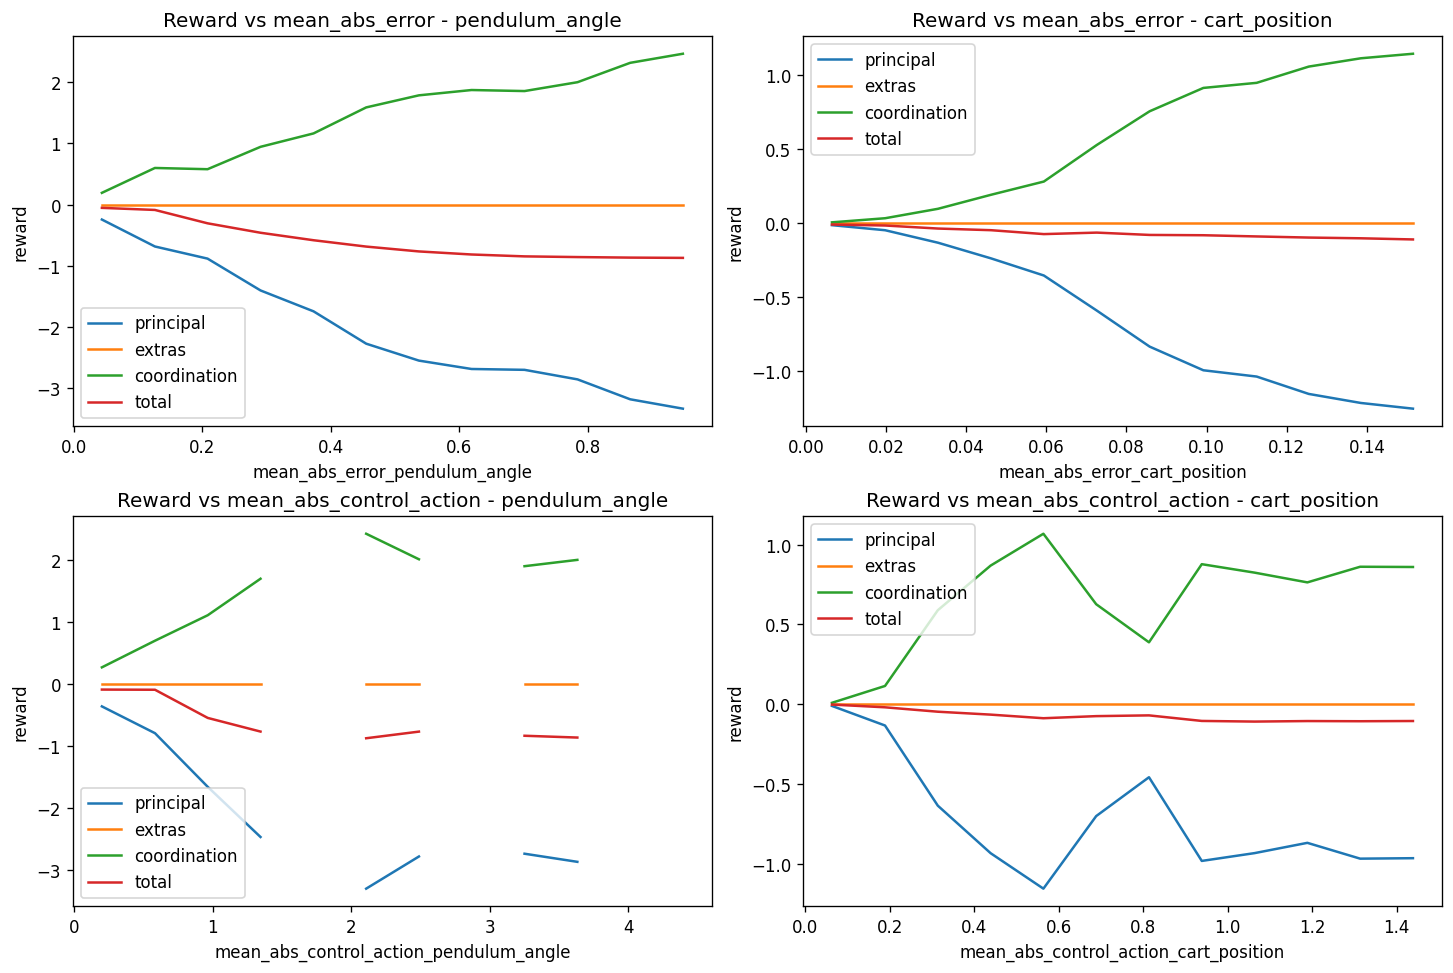

In [104]:
# ----------------------------
# Perfiles empíricos
# ----------------------------

fig, axes = plt.subplots(2, len(SECTION_7_TARGET_VARS), figsize=(6 * len(SECTION_7_TARGET_VARS), 8), constrained_layout=True)
if len(SECTION_7_TARGET_VARS) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col, var_obj in enumerate(SECTION_7_TARGET_VARS):
    error_profile = profile(
        frame=behavior_df,
        x_col=f"mean_abs_error_{var_obj}",
        y_cols=[f"principal_loop_{var_obj}", f"extra_total_{var_obj}", f"coordination_total_{var_obj}", f"assigned_reward_{var_obj}"],
        bins=SECTION_7_PROFILE_BINS,
    )
    band_low, band_high = band_range(config_main, band_cfg, var_obj)

    axes[0, col].plot(error_profile[f"mean_abs_error_{var_obj}"], error_profile[f"principal_loop_{var_obj}"], label="principal")
    axes[0, col].plot(error_profile[f"mean_abs_error_{var_obj}"], error_profile[f"extra_total_{var_obj}"], label="extras")
    axes[0, col].plot(error_profile[f"mean_abs_error_{var_obj}"], error_profile[f"coordination_total_{var_obj}"], label="coordination")
    axes[0, col].plot(error_profile[f"mean_abs_error_{var_obj}"], error_profile[f"assigned_reward_{var_obj}"], label="total")
    if band_cfg["enabled"] is True:
        axes[0, col].axvspan(0.0, max(abs(band_low), abs(band_high)), alpha=0.15, color="lightsteelblue")
    axes[0, col].set_title(f"Reward vs mean_abs_error - {var_obj}")
    axes[0, col].set_xlabel(f"mean_abs_error_{var_obj}")
    axes[0, col].set_ylabel("reward")
    axes[0, col].legend()

    control_profile = profile(
        frame=behavior_df,
        x_col=f"mean_abs_control_action_{var_obj}",
        y_cols=[f"principal_loop_{var_obj}", f"extra_total_{var_obj}", f"coordination_total_{var_obj}", f"assigned_reward_{var_obj}"],
        bins=SECTION_7_PROFILE_BINS,
    )
    axes[1, col].plot(control_profile[f"mean_abs_control_action_{var_obj}"], control_profile[f"principal_loop_{var_obj}"], label="principal")
    axes[1, col].plot(control_profile[f"mean_abs_control_action_{var_obj}"], control_profile[f"extra_total_{var_obj}"], label="extras")
    axes[1, col].plot(control_profile[f"mean_abs_control_action_{var_obj}"], control_profile[f"coordination_total_{var_obj}"], label="coordination")
    axes[1, col].plot(control_profile[f"mean_abs_control_action_{var_obj}"], control_profile[f"assigned_reward_{var_obj}"], label="total")
    axes[1, col].set_title(f"Reward vs mean_abs_control_action - {var_obj}")
    axes[1, col].set_xlabel(f"mean_abs_control_action_{var_obj}")
    axes[1, col].set_ylabel("reward")
    axes[1, col].legend()

plt.show()

export_figure(fig, ANALYSIS_SUBDIRS["reward_behavior"], "06_empirical_reward_profiles")


### Interpretación de la sección 7

Estos perfiles muestran la reward sobre el dominio realmente explorado por la política.  
Esa diferencia es fundamental. La teoría dice cómo podría comportarse el incentivo; estos perfiles muestran cómo se manifestó en la práctica sobre los intervalos que sí ocurrieron.

La fila superior responde a la pregunta: **qué reward media se observó cuando el error medio tomó distintos niveles**.  
Aquí conviene observar si la reward total cae, sube o cambia de forma coherente a medida que el sistema se aleja de la banda deseada. Cuando la curva total mejora solo gracias a extras o coordinación, pero la principal se mantiene débil, la base del shaping puede estar entregando poca información.

La fila inferior responde a la pregunta complementaria: **qué reward media se observó cuando aumentó el esfuerzo de control**.  
Una reward bien sintonizada no necesariamente debe castigar de forma monótona todo aumento de control. Lo deseable es que distinga entre esfuerzo útil y esfuerzo excesivo. Si la reward cae demasiado pronto aun cuando el error sigue siendo alto, la señal puede desalentar correcciones necesarias.

La comparación simultánea entre principal, extras, coordinación y total ayuda a separar funciones.  
La principal debería sostener el criterio base de desempeño. Los extras deberían modular o reforzar conductas específicas. La coordinación debería aportar estructura colectiva, no reemplazar la base. Cuando esa jerarquía se invierte, el tuning siguiente suele requerir corrección de escala más que un simple cambio menor.

Esta sección es una bisagra entre diagnóstico y rediseño.  
Permite decidir si el próximo ajuste debe hacerse en la reward principal, en la magnitud de los shaping auxiliares o en la proporción entre ambos.


## 8. Densidad step-level en el espacio error-control

Esta sección ubica la experiencia real del sistema en el plano error-control.  
Su objetivo es mostrar dónde pasa efectivamente el tiempo la simulación.


In [105]:
# ----------------------------
# Input de la sección 8
# ----------------------------

SECTION_8_TARGET_VARS = target_var_objs
SECTION_8_HEXBIN_SIZE = STEP_HEXBIN_SIZE


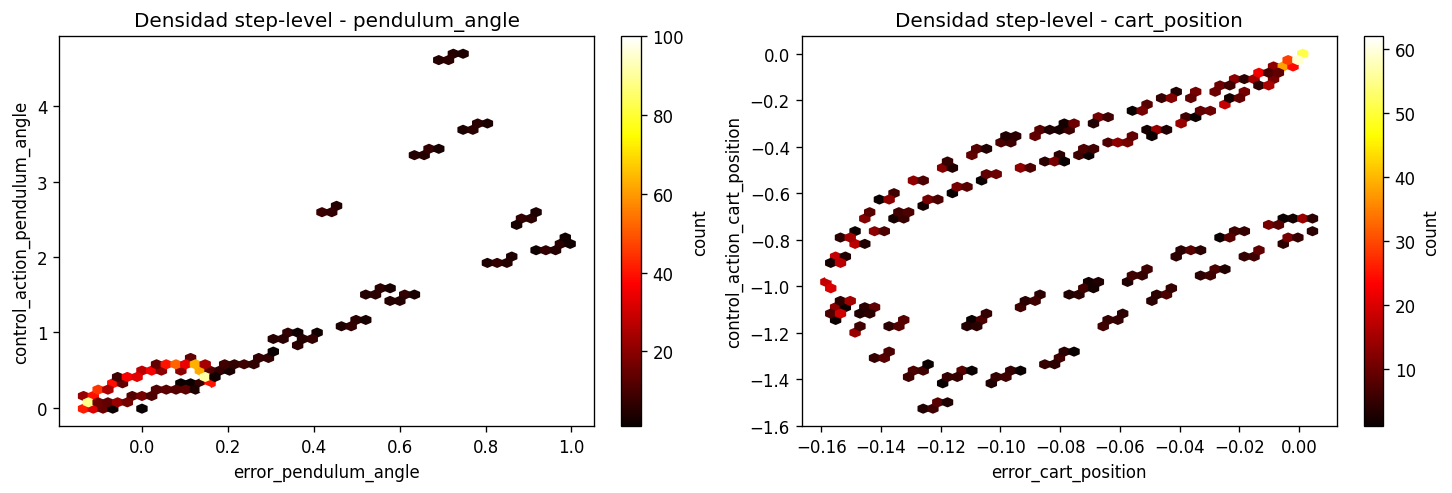

In [106]:
# ----------------------------
# Densidad step-level
# ----------------------------

fig, axes = plt.subplots(1, len(SECTION_8_TARGET_VARS), figsize=(6 * len(SECTION_8_TARGET_VARS), 4), constrained_layout=True)
if len(SECTION_8_TARGET_VARS) == 1:
    axes = [axes]

for ax, var_obj in zip(axes, SECTION_8_TARGET_VARS):
    meta = variable_catalog_df[variable_catalog_df["var_obj"] == var_obj].iloc[0]
    heatmap = ax.hexbin(
        step_df[meta["error_col"]],
        step_df[meta["control_action_col"]],
        gridsize=SECTION_8_HEXBIN_SIZE,
        mincnt=1,
        cmap="hot",
    )
    band_low, band_high = band_range(config_main, band_cfg, var_obj)
    if band_cfg["enabled"] is True:
        ax.axvspan(band_low, band_high, alpha=0.15, color="lightsteelblue")
    ax.set_title(f"Densidad step-level - {var_obj}")
    ax.set_xlabel(meta["error_col"])
    ax.set_ylabel(meta["control_action_col"])
    plt.colorbar(heatmap, ax=ax, label="count")

plt.show()

export_figure(fig, ANALYSIS_SUBDIRS["reward_behavior"], "07_step_density_error_control")


### Interpretación de la sección 8

Este mapa no muestra reward; muestra **ocupación real del espacio**.  
Por eso su valor es enorme: permite saber si la política opera dentro de la región donde la reward fue diseñada para ser más informativa o si, en cambio, permanece en zonas donde el shaping tiene poca capacidad de guía.

La lectura correcta consiste en comparar tres elementos a la vez: la nube densa, la franja sombreada y la severidad del control.  
Si la mayor densidad aparece cerca de la banda útil con control moderado, la geometría de reward tiene más probabilidades de estar trabajando en la región adecuada. Si la densidad se concentra muy lejos de esa banda y además con control alto, el sistema podría estar atrapado en una zona donde el incentive landscape no favorece una transición clara hacia estabilización.

Este gráfico es especialmente útil para no sobreinterpretar superficies teóricas.  
Una reward puede estar muy bien diseñada sobre el papel y aun así resultar poco efectiva si la política casi nunca visita la región donde esa reward tiene pendiente útil. En ese caso, el problema de diseño no siempre es la forma local de la reward; a veces es la distancia entre la zona visitada y la zona donde el shaping fue pensado para operar.

La decisión práctica que suele nacer de esta figura es muy concreta:  
si la ocupación se concentra lejos de la banda útil, conviene preguntarse si el shaping debe volverse más informativo en esas zonas de acceso. Si la ocupación ya está cerca de la banda pero el control sigue siendo alto, entonces el ajuste probablemente deba focalizarse en penalties o en coordinación fina.


## 9. Mapa interval-level de comportamiento y reward

Esta sección combina ocupación observada y señal de aprendizaje.  
Cada hexágono resume un conjunto de intervalos con error medio y esfuerzo medio similares, coloreados por la reward media asignada.


In [107]:
# ----------------------------
# Input de la sección 9
# ----------------------------

SECTION_9_TARGET_VARS = target_var_objs
SECTION_9_HEXBIN_SIZE = INTERVAL_HEXBIN_SIZE


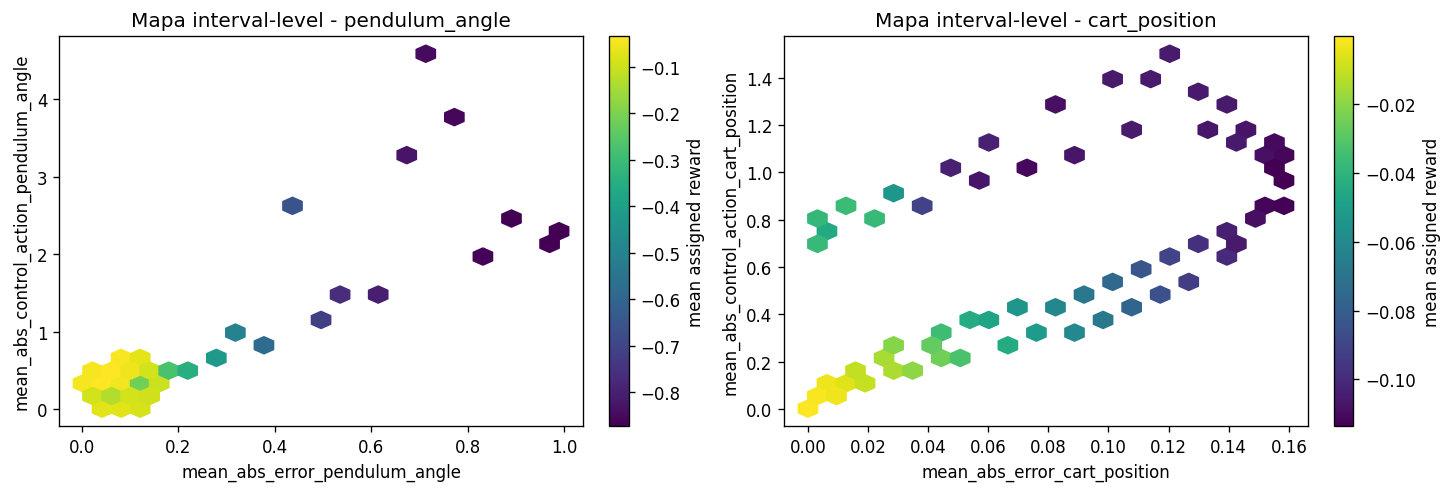

In [108]:
# ----------------------------
# Mapa interval-level
# ----------------------------

fig, axes = plt.subplots(1, len(SECTION_9_TARGET_VARS), figsize=(6 * len(SECTION_9_TARGET_VARS), 4), constrained_layout=True)
if len(SECTION_9_TARGET_VARS) == 1:
    axes = [axes]

for ax, var_obj in zip(axes, SECTION_9_TARGET_VARS):
    heatmap = ax.hexbin(
        behavior_df[f"mean_abs_error_{var_obj}"],
        behavior_df[f"mean_abs_control_action_{var_obj}"],
        C=behavior_df[f"assigned_reward_{var_obj}"],
        reduce_C_function=np.mean,
        gridsize=SECTION_9_HEXBIN_SIZE,
        mincnt=1,
        cmap="viridis",
    )
    band_low, band_high = band_range(config_main, band_cfg, var_obj)
    if band_cfg["enabled"] is True:
        ax.axvspan(0.0, max(abs(band_low), abs(band_high)), alpha=0.15, color="lightsteelblue")
    ax.set_title(f"Mapa interval-level - {var_obj}")
    ax.set_xlabel(f"mean_abs_error_{var_obj}")
    ax.set_ylabel(f"mean_abs_control_action_{var_obj}")
    plt.colorbar(heatmap, ax=ax, label="mean assigned reward")

plt.show()

export_figure(fig, ANALYSIS_SUBDIRS["reward_behavior"], "08_interval_reward_map")


### Interpretación de la sección 9

Este mapa sintetiza tres dimensiones al mismo tiempo: error medio, esfuerzo medio y reward media asignada.  
Por eso suele ser una de las figuras más valiosas para cerrar una ronda de análisis. A diferencia del mapa step-level, aquí no solo importa dónde estuvo el sistema, sino también **cómo fue premiado allí**.

La lectura práctica consiste en distinguir tres tipos de regiones:

1. **Regiones frecuentes con reward baja.**  
   Estas zonas son candidatas directas a rediseño, porque concentran experiencia real con señal poco útil o poco atractiva.

2. **Regiones frecuentes con reward alta.**  
   Aquí el shaping ya está alineado con el comportamiento que la política visita. La pregunta deja de ser “cómo corregir” y pasa a ser “cómo consolidar”.

3. **Regiones poco frecuentes con reward alta.**  
   Estas zonas pueden representar objetivos bien definidos por la reward, pero todavía poco alcanzados por la política. En ese caso conviene decidir si se quiere atraer más experiencia hacia ellas o si el mapa está premiando un comportamiento que en la práctica cuesta demasiado alcanzar.

La comparación con la banda sombreada vuelve a ser importante.  
Si los hexágonos mejor premiados se ubican dentro o cerca de la banda deseada, la reward está orientando bien la operación. Si los mejores valores aparecen lejos de esa referencia, la arquitectura del incentivo puede estar sobrerrecompensando un comportamiento que no coincide con el criterio físico principal.

Esta figura transforma la intuición general del episodio en una decisión de diseño localizada.  
Permite señalar **qué región concreta del espacio comportamiento-reward debería ser modificada** por la siguiente ronda de tuning.


## 10. Balance numérico de la composición de reward

Hasta aquí la composición se ha leído visualmente.  
Esta sección la cuantifica. El objetivo es medir cuánto pesa cada bloque dentro de la reward total observada.


In [109]:
# ----------------------------
# Input de la sección 10
# ----------------------------

SECTION_10_TARGET_VARS = target_var_objs


,var_obj,mean_abs_principal,mean_abs_extras,mean_abs_coordination,mean_abs_assigned_reward,share_principal_over_assigned,share_extras_over_assigned,share_coordination_over_assigned,max_abs_principal,max_abs_extras,max_abs_coordination,max_abs_assigned_reward
0,pendulum_angle,0.893611,0.0,0.692168,0.201443,4.436048,0.0,3.436048,3.381685,0.0,2.507723,0.873962
1,cart_position,0.608647,0.0,0.545647,0.063000,9.661101,0.0,8.661101,1.274419,0.0,1.162615,0.114208


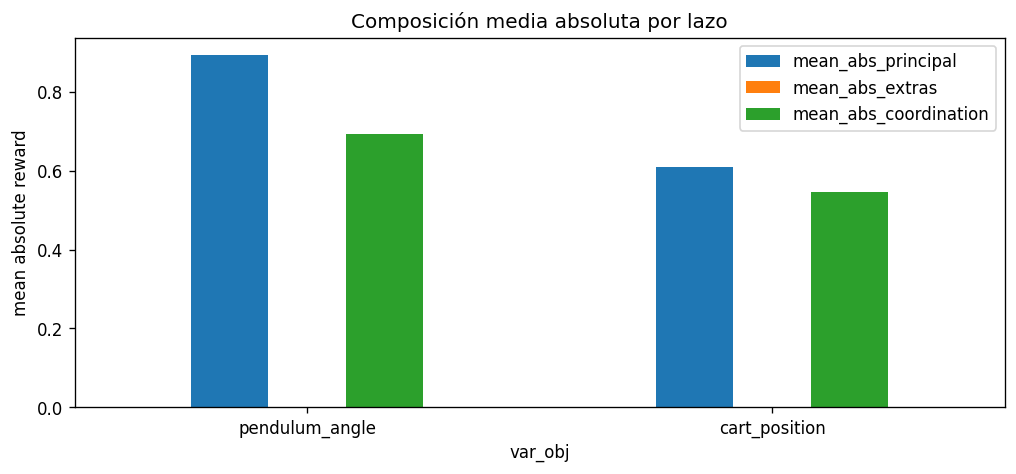

,global_mean_abs_interval_reward,global_mean_abs_principal,global_mean_abs_extras,global_mean_abs_coordination,coordination_over_global,extras_over_global,principal_over_global
0,0.264443,1.502258,0.0,1.237815,4.680843,0.0,5.680843


<Figure size 768x576 with 0 Axes>

In [110]:
# ----------------------------
# Balance numérico de composición
# ----------------------------

composition_rows = []
for var_obj in SECTION_10_TARGET_VARS:
    assigned_abs_mean = behavior_df[f"assigned_reward_{var_obj}"].abs().mean()
    principal_abs_mean = behavior_df[f"principal_loop_{var_obj}"].abs().mean()
    extras_abs_mean = behavior_df[f"extra_total_{var_obj}"].abs().mean()
    coord_abs_mean = behavior_df[f"coordination_total_{var_obj}"].abs().mean()

    composition_rows.append({
        "var_obj": var_obj,
        "mean_abs_principal": principal_abs_mean,
        "mean_abs_extras": extras_abs_mean,
        "mean_abs_coordination": coord_abs_mean,
        "mean_abs_assigned_reward": assigned_abs_mean,
        "share_principal_over_assigned": principal_abs_mean / assigned_abs_mean if assigned_abs_mean > 0 else 0.0,
        "share_extras_over_assigned": extras_abs_mean / assigned_abs_mean if assigned_abs_mean > 0 else 0.0,
        "share_coordination_over_assigned": coord_abs_mean / assigned_abs_mean if assigned_abs_mean > 0 else 0.0,
        "max_abs_principal": behavior_df[f"principal_loop_{var_obj}"].abs().max(),
        "max_abs_extras": behavior_df[f"extra_total_{var_obj}"].abs().max(),
        "max_abs_coordination": behavior_df[f"coordination_total_{var_obj}"].abs().max(),
        "max_abs_assigned_reward": behavior_df[f"assigned_reward_{var_obj}"].abs().max(),
    })

composition_df = pd.DataFrame(composition_rows)
display(composition_df)

plot_df = composition_df.set_index("var_obj")[["mean_abs_principal", "mean_abs_extras", "mean_abs_coordination"]]
plot_df.plot(kind="bar", figsize=(10, 4))
plt.title("Composición media absoluta por lazo")
plt.xlabel("var_obj")
plt.ylabel("mean absolute reward")
plt.xticks(rotation=0)
plt.show()

global_composition_df = pd.DataFrame([{
    "global_mean_abs_interval_reward": behavior_df["global_interval_reward"].abs().mean(),
    "global_mean_abs_principal": behavior_df["principal_total_rebuilt"].abs().mean(),
    "global_mean_abs_extras": behavior_df["extra_total_rebuilt"].abs().mean(),
    "global_mean_abs_coordination": behavior_df["coordination_total_rebuilt"].abs().mean(),
    "coordination_over_global": behavior_df["coordination_total_rebuilt"].abs().mean() / behavior_df["global_interval_reward"].abs().mean() if behavior_df["global_interval_reward"].abs().mean() > 0 else 0.0,
    "extras_over_global": behavior_df["extra_total_rebuilt"].abs().mean() / behavior_df["global_interval_reward"].abs().mean() if behavior_df["global_interval_reward"].abs().mean() > 0 else 0.0,
    "principal_over_global": behavior_df["principal_total_rebuilt"].abs().mean() / behavior_df["global_interval_reward"].abs().mean() if behavior_df["global_interval_reward"].abs().mean() > 0 else 0.0,
}])

display(global_composition_df)

export_figure(plt.gcf(), ANALYSIS_SUBDIRS["reward_behavior"], "09_reward_composition")
export_table(composition_df, ANALYSIS_SUBDIRS["reward_behavior"], "09_reward_composition", excel=True)
export_table(global_composition_df, ANALYSIS_SUBDIRS["reward_behavior"], "09_global_composition", excel=True)


### Interpretación de la sección 10

Esta sección cuantifica lo que las curvas sugieren.  
La tabla por lazo muestra cuánto pesa cada bloque en términos de magnitud absoluta media y de proporción respecto de la reward asignada. Esta lectura es importante porque un bloque puede verse “visible” en la figura y, sin embargo, aportar poco en términos numéricos frente al total.

La columna `share_principal_over_assigned` indica cuánto de la señal de aprendizaje está siendo sostenida por la base del shaping.  
Cuando ese valor domina claramente, la recompensa principal está haciendo el trabajo central. Cuando cae demasiado y son los extras o la coordinación quienes sostienen la magnitud de la señal, la arquitectura puede estar excesivamente apoyada en mecanismos complementarios.

La columna `share_coordination_over_assigned` merece una lectura específica.  
Un valor muy bajo no significa necesariamente que la coordinación esté mal implementada; puede reflejar que su rol fue intencionalmente moderado. Lo importante es que ese valor sea coherente con la intención de diseño. Si se esperaba una coordinación claramente visible y su proporción es marginal, el parámetro a revisar no es solo el `global_weight`; también debe revisarse si hubo suficiente progreso de tarea y suficiente crédito correctivo.

La tabla global resume el balance a nivel del intervalo completo.  
Esta vista es útil para entender la jerarquía real entre bloques. En una arquitectura bien alineada, la principal suele sostener la base, mientras que extras y coordinación modulan. Cuando el reparto se invierte, conviene preguntarse si el sistema está aprendiendo la conducta central o si depende de incentivos secundarios para orientarse.

La figura de barras facilita una comparación rápida entre lazos.  
Si uno de ellos depende mucho más de extras o coordinación que otro, esa asimetría puede explicar diferencias de estabilidad, de velocidad de aprendizaje o de sensibilidad a condiciones iniciales.

Esta sección convierte el análisis en criterio cuantitativo.  
Después de verla, el diseñador ya no debería hablar de “se ve grande” o “se ve pequeño”, sino de **qué proporción real de la señal de aprendizaje está siendo aportada por cada bloque**.


## 10B. Diagnóstico de coordinación y cancelación entre lazos

Si los lazos colaboran, `u_total` consolida el esfuerzo. Si se pelean, la suma efectiva se achica aunque cada lazo esté actuando con magnitud alta. Esta sección mide ese fenómeno sobre el episodio seleccionado.


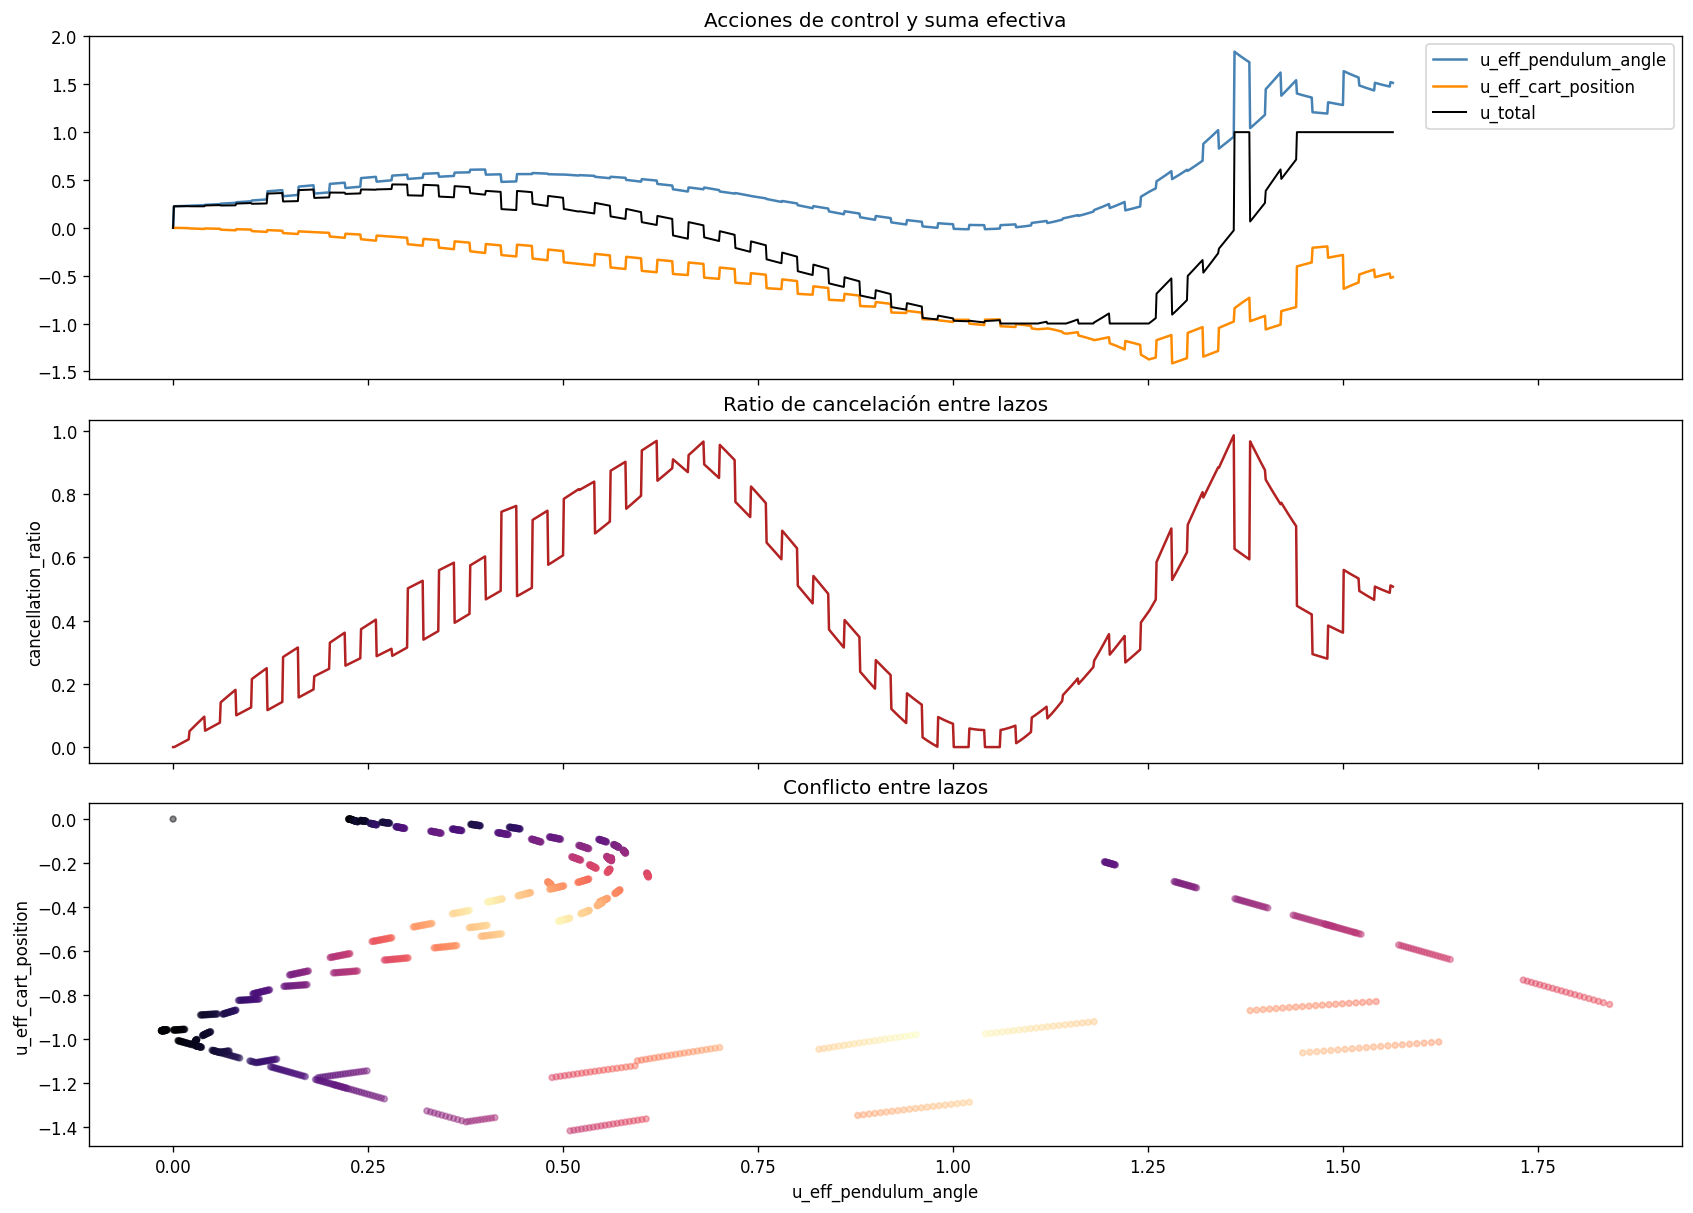

,metric,value
0,mean_cancellation_ratio,0.447859
1,p90_cancellation_ratio,0.871902
2,mean_rolling_corr,-0.083973
3,mean_abs_u_a,0.489660
4,mean_abs_u_b,0.561784
5,mean_abs_u_total,0.525656


In [111]:
SECTION_COORD_ROLLING = max(15, ROLLING_WINDOW)

coordination_diag_df = pd.DataFrame()
coordination_summary_df = pd.DataFrame()

if len(target_var_objs) >= 2:
    coord_var_a = target_var_objs[0]
    coord_var_b = target_var_objs[1]

    u_a_col = choose_first_existing(
        [f"u_eff_{coord_var_a}", f"control_action_{coord_var_a}"],
        step_df.columns,
    )
    u_b_col = choose_first_existing(
        [f"u_eff_{coord_var_b}", f"control_action_{coord_var_b}"],
        step_df.columns,
    )
    u_total_col = choose_first_existing(["u_total"], step_df.columns)

    if u_a_col and u_b_col:
        coordination_diag_df = pd.DataFrame(
            {
                "t_sec": step_df["t_sec"].astype(float),
                "u_a": step_df[u_a_col].astype(float),
                "u_b": step_df[u_b_col].astype(float),
                "u_total": step_df[u_total_col].astype(float) if u_total_col else step_df[u_a_col].astype(float) + step_df[u_b_col].astype(float),
            }
        )
        denominator = coordination_diag_df["u_a"].abs() + coordination_diag_df["u_b"].abs() + 1e-9
        coordination_diag_df["cancellation_ratio"] = np.clip(
            (coordination_diag_df["u_a"].abs() + coordination_diag_df["u_b"].abs() - coordination_diag_df["u_total"].abs()) / denominator,
            0.0,
            1.0,
        )
        coordination_diag_df["rolling_corr"] = coordination_diag_df["u_a"].rolling(
            SECTION_COORD_ROLLING,
            min_periods=max(5, SECTION_COORD_ROLLING // 2),
        ).corr(coordination_diag_df["u_b"])

        coordination_summary_df = pd.DataFrame(
            [
                {"metric": "mean_cancellation_ratio", "value": float(coordination_diag_df["cancellation_ratio"].mean())},
                {"metric": "p90_cancellation_ratio", "value": float(coordination_diag_df["cancellation_ratio"].quantile(0.90))},
                {"metric": "mean_rolling_corr", "value": float(coordination_diag_df["rolling_corr"].dropna().mean())},
                {"metric": "mean_abs_u_a", "value": float(coordination_diag_df["u_a"].abs().mean())},
                {"metric": "mean_abs_u_b", "value": float(coordination_diag_df["u_b"].abs().mean())},
                {"metric": "mean_abs_u_total", "value": float(coordination_diag_df["u_total"].abs().mean())},
            ]
        )

        fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
        axes[0].plot(coordination_diag_df["t_sec"], coordination_diag_df["u_a"], label=u_a_col, color="steelblue")
        axes[0].plot(coordination_diag_df["t_sec"], coordination_diag_df["u_b"], label=u_b_col, color="darkorange")
        axes[0].plot(coordination_diag_df["t_sec"], coordination_diag_df["u_total"], label=u_total_col or "u_total_rebuilt", color="black", linewidth=1.2)
        axes[0].set_title("Acciones de control y suma efectiva")
        axes[0].legend()

        axes[1].plot(coordination_diag_df["t_sec"], coordination_diag_df["cancellation_ratio"], color="firebrick")
        axes[1].set_title("Ratio de cancelación entre lazos")
        axes[1].set_ylabel("cancellation_ratio")

        axes[2].scatter(
            coordination_diag_df["u_a"],
            coordination_diag_df["u_b"],
            c=coordination_diag_df["cancellation_ratio"],
            cmap="magma",
            alpha=0.45,
            s=12,
        )
        axes[2].set_title("Conflicto entre lazos")
        axes[2].set_xlabel(u_a_col)
        axes[2].set_ylabel(u_b_col)
        plt.show()

        display(coordination_summary_df)
        export_figure(fig, ANALYSIS_SUBDIRS["episodes"], "02_coordination_diagnostics")
        export_table(coordination_summary_df, ANALYSIS_SUBDIRS["episodes"], "02_coordination_summary", excel=True)
    else:
        display(Markdown("No se encontraron columnas suficientes para comparar dos lazos de control en el episodio seleccionado."))
else:
    display(Markdown("La corrida solo expone un lazo objetivo en este notebook; no aplica el diagnóstico de cancelación entre lazos."))


## 10C. Radiografía empírica de hiperparámetros críticos

El inventario inicial dice qué parámetros existen. Esta radiografía agrega evidencia observada, una lectura diagnóstica y una recomendación preliminar para los parámetros con mayor probabilidad de mover el comportamiento de la próxima corrida.


In [112]:
band_occupancy = {}
error_over_band_ratio = {}
control_load_ratio = {}

for var_obj in target_var_objs:
    band_low, band_high = stabilization_band_raw(config_main, var_obj)
    band_limit = max(abs(band_low), abs(band_high))
    band_occupancy[var_obj] = float((behavior_df[f"mean_abs_error_{var_obj}"] <= band_limit).mean())
    error_over_band_ratio[var_obj] = float(
        behavior_df[f"mean_abs_error_{var_obj}"].mean() / max(band_limit, 1e-9)
    )
    control_load_ratio[var_obj] = float(
        behavior_df[f"mean_abs_control_action_{var_obj}"].mean()
        / max(metric_range_abs(normalization_cfg, var_obj, "u", fallback=1.0), 1e-9)
    )

coord_global_share = float(global_composition_df["coordination_over_global"].iloc[0]) if "global_composition_df" in globals() else np.nan
principal_global_share = float(global_composition_df["principal_over_global"].iloc[0]) if "global_composition_df" in globals() else np.nan
cancellation_mean = float(
    coordination_summary_df.loc[coordination_summary_df["metric"] == "mean_cancellation_ratio", "value"].iloc[0]
) if len(coordination_summary_df) > 0 else np.nan

def principal_weight_action(var_obj, feature_name):
    share = float(
        composition_df.loc[composition_df["var_obj"] == var_obj, "share_principal_over_assigned"].iloc[0]
    )
    err_ratio = error_over_band_ratio[var_obj]
    control_ratio = control_load_ratio[var_obj]

    if feature_name == "L_e":
        if err_ratio > 1.5 and share < 0.65:
            return "subir", "La corrida opera lejos de banda y la reward principal no domina todavía la señal."
        if err_ratio < 0.8 and share > 0.70:
            return "mantener", "La principal ya es visible y trabaja en una región cercana a banda."
        return "revisar", "La penalización de error es visible, pero su dominancia todavía no es concluyente."

    if feature_name == "L_u":
        if control_ratio > 0.45:
            return "subir", "El esfuerzo efectivo medio es alto respecto al rango normalizado."
        if control_ratio < 0.15:
            return "mantener", "El esfuerzo efectivo no parece ser el cuello dominante."
        return "revisar", "La carga de control es intermedia y conviene contrastarla con la dinámica física."

    if feature_name == "L_edot":
        if err_ratio < 1.0 and share > 0.60:
            return "mantener", "La corrección ya ocurre cerca de banda con una principal activa."
        return "revisar", "La amortiguación sigue siendo relevante, pero no domina el diagnóstico por sí sola."

    return "revisar", "No hay heurística automática fuerte para este término."

radiography_rows = []
for var_obj in target_var_objs:
    for feature_name in ["L_e", "L_edot", "L_u"]:
        if feature_name not in principal_features:
            continue
        action, diagnosis = principal_weight_action(var_obj, feature_name)
        radiography_rows.append(
            {
                "block": "principal_reward",
                "parameter": f"{feature_name}.weight::{var_obj}",
                "path": f"reward_base.reward_calculation.principal_reward.features.{feature_name}.weight",
                "current_value": principal_features[feature_name]["weight"],
                "observed_evidence": f"principal_share={float(composition_df.loc[composition_df['var_obj'] == var_obj, 'share_principal_over_assigned'].iloc[0]):.3f}; error_over_band={error_over_band_ratio[var_obj]:.3f}; control_load={control_load_ratio[var_obj]:.3f}",
                "diagnostic_conclusion": diagnosis,
                "recommended_action": action,
            }
        )

    radiography_rows.append(
        {
            "block": "bandwidth_bonus",
            "parameter": f"band_occupancy::{var_obj}",
            "path": f"reward_base.reward_calculation.extra_rewards.bonus_approach.bandwidth_bonus.max_total_band_bonus.{var_obj}",
            "current_value": band_cfg["max_total_band_bonus"][var_obj],
            "observed_evidence": f"band_occupancy={band_occupancy[var_obj]:.3f}",
            "diagnostic_conclusion": "La banda se activa muy poco sobre los intervalos observados." if band_occupancy[var_obj] < 0.08 else "La banda sí aparece en una fracción visible del comportamiento observado.",
            "recommended_action": "ensanchar banda" if band_occupancy[var_obj] < 0.08 else ("estrechar banda" if band_occupancy[var_obj] > 0.60 else "mantener"),
        }
    )

radiography_rows.append(
    {
        "block": "coordination_reward",
        "parameter": "global_weight",
        "path": "reward_base.reward_calculation.coordination_reward.global_weight",
        "current_value": coord_cfg["global_weight"],
        "observed_evidence": f"coordination_over_global={coord_global_share:.3f}; mean_cancellation_ratio={cancellation_mean:.3f}" if not np.isnan(coord_global_share) else "coordination metrics unavailable",
        "diagnostic_conclusion": "La coordinación aparece subescalada frente al total." if (not np.isnan(coord_global_share) and coord_global_share < 0.05) else ("La coordinación ya tiene presencia visible; conviene vigilar conflicto entre lazos." if not np.isnan(coord_global_share) else "No hubo evidencia suficiente para estimar el peso coordinativo."),
        "recommended_action": "subir" if (not np.isnan(coord_global_share) and coord_global_share < 0.05) else ("bajar" if (not np.isnan(coord_global_share) and coord_global_share > 0.25 and not np.isnan(cancellation_mean) and cancellation_mean > 0.25) else "mantener"),
    }
)
radiography_rows.append(
    {
        "block": "coordination_reward",
        "parameter": "epsilon_credit",
        "path": "reward_base.reward_calculation.coordination_reward.epsilon_credit",
        "current_value": coord_cfg["epsilon_credit"],
        "observed_evidence": f"mean_cancellation_ratio={cancellation_mean:.3f}" if not np.isnan(cancellation_mean) else "coordination diagnostics unavailable",
        "diagnostic_conclusion": "Existe cancelación visible; revisar reparto de crédito además del peso global." if (not np.isnan(cancellation_mean) and cancellation_mean > 0.25) else "No hay evidencia fuerte de conflicto persistente entre lazos en el episodio seleccionado.",
        "recommended_action": "revisar por saturación" if (not np.isnan(cancellation_mean) and cancellation_mean > 0.25) else "mantener",
    }
)
radiography_rows.append(
    {
        "block": "training",
        "parameter": "epsilon_schedule",
        "path": "agent_base.*epsilon*",
        "current_value": f"first={float(summary_df['epsilon'].iloc[0]):.4f}; last={float(summary_df['epsilon'].iloc[-1]):.4f}",
        "observed_evidence": f"reward_first_last_delta={float(learning_window_df.loc[learning_window_df['window'] == 'last_window', 'total_reward_mean'].iloc[0] - learning_window_df.loc[learning_window_df['window'] == 'first_window', 'total_reward_mean'].iloc[0]):.4f}",
        "diagnostic_conclusion": "Hubo mejora neta del reward medio entre ventanas." if float(learning_window_df.loc[learning_window_df['window'] == 'last_window', 'total_reward_mean'].iloc[0]) > float(learning_window_df.loc[learning_window_df['window'] == 'first_window', 'total_reward_mean'].iloc[0]) else "La mejora entre primeras y últimas ventanas no es concluyente.",
        "recommended_action": "mantener" if float(learning_window_df.loc[learning_window_df['window'] == 'last_window', 'total_reward_mean'].iloc[0]) > float(learning_window_df.loc[learning_window_df['window'] == 'first_window', 'total_reward_mean'].iloc[0]) else "revisar por irrelevancia observada",
    }
)

hyperparameter_radiography_df = pd.DataFrame(radiography_rows)
display(hyperparameter_radiography_df)

export_table(
    hyperparameter_radiography_df,
    ANALYSIS_SUBDIRS["hyperparameters"],
    "02_hyperparameter_radiography",
    excel=True,
)


,block,parameter,path,current_value,observed_evidence,diagnostic_conclusion,recommended_action
0,principal_reward,L_e.weight::pendulum_angle,reward_base.reward_calculation.principal_rewar...,0.75,principal_share=4.436; error_over_band=9.766; ...,"La penalización de error es visible, pero su d...",revisar
1,principal_reward,L_edot.weight::pendulum_angle,reward_base.reward_calculation.principal_rewar...,0.15,principal_share=4.436; error_over_band=9.766; ...,"La amortiguación sigue siendo relevante, pero ...",revisar
2,principal_reward,L_u.weight::pendulum_angle,reward_base.reward_calculation.principal_rewar...,0.1,principal_share=4.436; error_over_band=9.766; ...,El esfuerzo efectivo medio es alto respecto al...,subir
3,bandwidth_bonus,band_occupancy::pendulum_angle,reward_base.reward_calculation.extra_rewards.b...,1.5,band_occupancy=0.051,La banda se activa muy poco sobre los interval...,ensanchar banda
4,principal_reward,L_e.weight::cart_position,reward_base.reward_calculation.principal_rewar...,0.75,principal_share=9.661; error_over_band=0.744; ...,La principal ya es visible y trabaja en una re...,mantener
5,principal_reward,L_edot.weight::cart_position,reward_base.reward_calculation.principal_rewar...,0.15,principal_share=9.661; error_over_band=0.744; ...,La corrección ya ocurre cerca de banda con una...,mantener
6,principal_reward,L_u.weight::cart_position,reward_base.reward_calculation.principal_rewar...,0.1,principal_share=9.661; error_over_band=0.744; ...,El esfuerzo efectivo medio es alto respecto al...,subir
7,bandwidth_bonus,band_occupancy::cart_position,reward_base.reward_calculation.extra_rewards.b...,1.5,band_occupancy=0.620,La banda sí aparece en una fracción visible de...,estrechar banda
8,coordination_reward,global_weight,reward_base.reward_calculation.coordination_re...,0.3,coordination_over_global=4.681; mean_cancellat...,La coordinación ya tiene presencia visible; co...,bajar
9,coordination_reward,epsilon_credit,reward_base.reward_calculation.coordination_re...,0.000001,mean_cancellation_ratio=0.448,Existe cancelación visible; revisar reparto de...,revisar por saturación


## 11. Impacto paramétrico local

Esta sección no usa una nueva corrida.  
Su propósito es ensayar cómo cambia la geometría del incentivo cuando se modifica un parámetro candidato, manteniendo todo lo demás fijo. La idea es que la siguiente intervención deje de ser intuitiva y pase a ser explícita.


In [113]:
# ----------------------------
# Input de la sección 11
# ----------------------------

SECTION_11_SWEEP_FAMILY = "coordination"      # principal | coordination
SECTION_11_VAR_OBJ = target_var_objs[0]
SECTION_11_FEATURE = "L_e"                 # solo para family='principal'
SECTION_11_PARAMETER = "global_weight"            # principal: weight | scaled | setpoint ; coordination: global_weight | progress_clip_max | epsilon_credit
SECTION_11_VALUES = [0.4, 0.8, 1.2, 1.6]
SECTION_11_ERROR_LEVEL = 0.05
SECTION_11_EDOT_LEVEL = 0.0
SECTION_11_CONTROL_LEVEL = 0.1
SECTION_11_PROGRESS_LEVEL = 0.20
SECTION_11_OTHER_RAW_CONTRIBUTION = 0.10


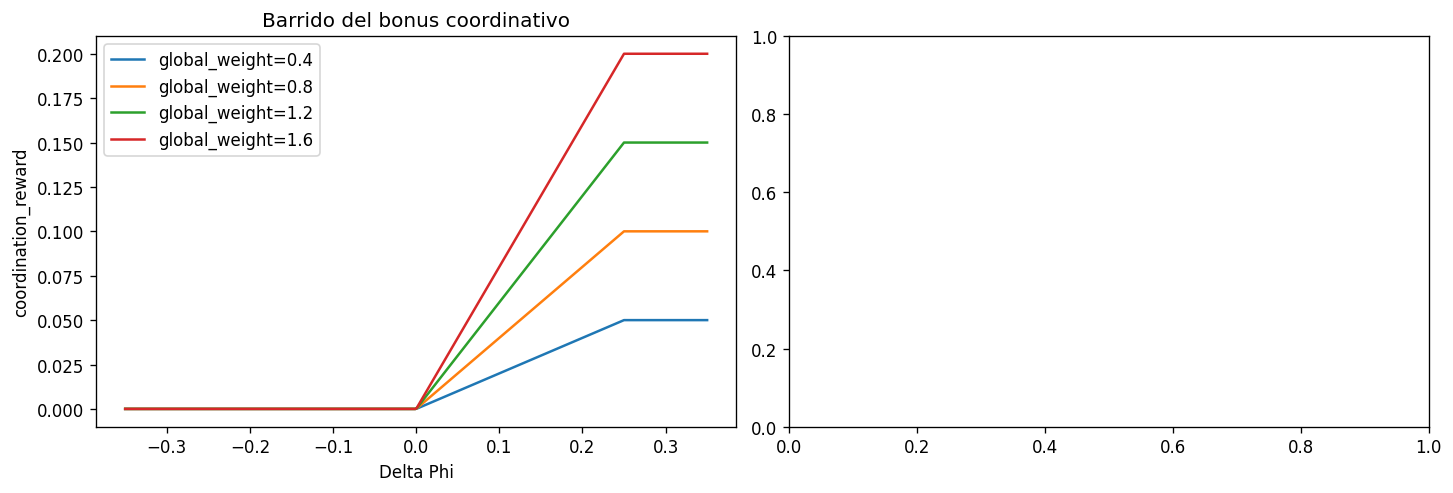

In [114]:
# ----------------------------
# Barrido paramétrico
# ----------------------------

def copy_principal_features(principal_features):
    return {key: dict(value) for key, value in principal_features.items()}

if SECTION_11_SWEEP_FAMILY == "principal":
    error_max = metric_range_abs(normalization_cfg, SECTION_11_VAR_OBJ, "e", fallback=1.0)
    control_max = metric_range_abs(normalization_cfg, SECTION_11_VAR_OBJ, "u", fallback=1.0)
    error_axis = np.linspace(0.0, error_max, 240)
    control_axis = np.linspace(0.0, control_max, 240)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for value in SECTION_11_VALUES:
        local_features = copy_principal_features(principal_features)
        local_features[SECTION_11_FEATURE][SECTION_11_PARAMETER] = value

        reward_vs_error = total_loop_proxy(
            config_main=config_main,
            principal_cfg=principal_cfg,
            normalization_cfg=normalization_cfg,
            principal_features=local_features,
            extra_cfg=extra_cfg,
            decision_steps=decision_steps,
            var_obj=SECTION_11_VAR_OBJ,
            error_level=error_axis,
            control_level=SECTION_11_CONTROL_LEVEL,
            edot_level=SECTION_11_EDOT_LEVEL,
        )

        reward_vs_control = total_loop_proxy(
            config_main=config_main,
            principal_cfg=principal_cfg,
            normalization_cfg=normalization_cfg,
            principal_features=local_features,
            extra_cfg=extra_cfg,
            decision_steps=decision_steps,
            var_obj=SECTION_11_VAR_OBJ,
            error_level=SECTION_11_ERROR_LEVEL,
            control_level=control_axis,
            edot_level=SECTION_11_EDOT_LEVEL,
        )

        axes[0].plot(error_axis, reward_vs_error, label=f"{SECTION_11_PARAMETER}={value}")
        axes[1].plot(control_axis, reward_vs_control, label=f"{SECTION_11_PARAMETER}={value}")

    axes[0].set_title(f"Barrido vs error - {SECTION_11_VAR_OBJ}")
    axes[0].set_xlabel("error_level")
    axes[0].set_ylabel("reward")
    axes[0].legend()

    axes[1].set_title(f"Barrido vs control - {SECTION_11_VAR_OBJ}")
    axes[1].set_xlabel("control_level")
    axes[1].set_ylabel("reward")
    axes[1].legend()

    plt.show()

else:
    progress_axis = np.linspace(-0.35, 0.35, 400)
    raw_axis = np.linspace(0.0, 0.4, 400)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for value in SECTION_11_VALUES:
        local_coord_cfg = dict(coord_cfg)
        local_coord_cfg[SECTION_11_PARAMETER] = value

        if SECTION_11_PARAMETER == "progress_clip_max":
            rewardable_progress = coordination_progress_rewardable(local_coord_cfg, progress_axis)
            reward_curve = coordination_reward_curve(coord_cfg["global_weight"], rewardable_progress, 0.5)
            axes[0].plot(progress_axis, reward_curve, label=f"{SECTION_11_PARAMETER}={value}")

        elif SECTION_11_PARAMETER == "global_weight":
            rewardable_progress = coordination_progress_rewardable(coord_cfg, progress_axis)
            reward_curve = coordination_reward_curve(value, rewardable_progress, 0.5)
            axes[0].plot(progress_axis, reward_curve, label=f"{SECTION_11_PARAMETER}={value}")

        elif SECTION_11_PARAMETER == "epsilon_credit":
            share_curve = coordination_credit_share(raw_axis, SECTION_11_OTHER_RAW_CONTRIBUTION, value)
            axes[1].plot(raw_axis, share_curve, label=f"{SECTION_11_PARAMETER}={value}")

    if SECTION_11_PARAMETER in ["progress_clip_max", "global_weight"]:
        axes[0].set_title("Barrido del bonus coordinativo")
        axes[0].set_xlabel("Delta Phi")
        axes[0].set_ylabel("coordination_reward")
        axes[0].legend()

    if SECTION_11_PARAMETER == "epsilon_credit":
        axes[1].set_title("Barrido de fracción de crédito")
        axes[1].set_xlabel("raw_credit propio")
        axes[1].set_ylabel("credit_share")
        axes[1].legend()

    plt.show()

export_figure(fig, ANALYSIS_SUBDIRS["reward_behavior"], "10_parametric_sweep")


### Interpretación de la sección 11

Esta sección debe leerse como un experimento local de diseño.  
No busca predecir exactamente la próxima corrida, sino mostrar la dirección causal más probable del cambio paramétrico antes de ejecutar una nueva simulación.

Cuando el barrido se realiza sobre la **reward principal**, la curva frente al error indica cómo cambia la sensibilidad de la reward al desvío, mientras que la curva frente al control muestra cómo ese mismo cambio impacta la tolerancia al esfuerzo.  
La lectura correcta consiste en preguntarse qué aspecto se quiere mover: mayor selectividad, mayor tolerancia, mayor gradiente o menor dominancia de un componente.

Modificar `weight` cambia la importancia relativa de una feature.  
Modificar `scaled` cambia la rapidez con la que esa feature se vuelve severa o laxa.  
Modificar `setpoint` desplaza el centro de mayor atractivo de esa contribución.  
Cada uno de estos cambios tiene una semántica distinta, y esta sección permite observarla sin mezclarla todavía con la dinámica completa del episodio.

Cuando el barrido se realiza sobre la **coordinación**, la interpretación cambia.  
`global_weight` escala el tamaño del bonus final. `progress_clip_max` limita el máximo progreso premiable. `epsilon_credit` regula cuánto del crédito se reparte de forma sensible cuando la contribución cruda es pequeña. En conjunto, estos parámetros no describen la forma de la reward base, sino la autoridad numérica y distributiva del bloque coordinativo.

La utilidad principal de esta sección es evitar cambios a ciegas.  
Después de mirar estas curvas, el diseñador debería poder formular una intervención en términos explícitos: por ejemplo, “se busca ensanchar la zona útil sin perder pendiente inicial”, o bien, “se busca que la coordinación deje de ser marginal sin convertirla en el bloque dominante”.

En ese sentido, esta sección es el puente directo entre análisis y acción.  
Su salida no es un diagnóstico, sino una hipótesis de tuning lista para probar en la siguiente corrida.


## 12. Hoja final de tuning

La función de este bloque es dejar por escrito la intervención propuesta.  
No se trata de resumir impresiones, sino de convertir la evidencia del notebook en una decisión trazable.


In [115]:
# ----------------------------
# Input de la sección 12
# ----------------------------

SECTION_12_TUNING_DECISIONS = [
    {
        "block": "principal_reward",
        "parameter": "",
        "current_value": "",
        "proposed_value": "",
        "evidence_section": "",
        "expected_effect": "",
        "priority": "",
    },
    {
        "block": "coordination_reward",
        "parameter": "",
        "current_value": "",
        "proposed_value": "",
        "evidence_section": "",
        "expected_effect": "",
        "priority": "",
    },
]


In [116]:
# ----------------------------
# Hoja de tuning
# ----------------------------

tuning_sheet_df = pd.DataFrame(SECTION_12_TUNING_DECISIONS)
display(tuning_sheet_df)


,block,parameter,current_value,proposed_value,evidence_section,expected_effect,priority
0,principal_reward,,,,,,
1,coordination_reward,,,,,,


### Interpretación de la sección 12

La hoja de tuning es el cierre operativo del notebook.  
Aquí el análisis deja de ser observacional y se transforma en decisión. Cada fila debe representar un cambio concreto, con su bloque, su parámetro, su valor actual, su valor propuesto, la evidencia que lo respalda y el efecto esperado.

El campo `evidence_section` no es un detalle administrativo.  
Su función es amarrar cada intervención a una evidencia visual o numérica específica del notebook. De ese modo, la propuesta deja de ser una intuición y pasa a ser una hipótesis argumentada.

El campo `expected_effect` debe redactarse en términos causales y observables.  
No conviene escribir frases vagas como “mejorar el aprendizaje”. Resulta más útil indicar algo como: “ensanchar la región favorable cerca de banda”, “reducir la dominancia del extra sobre la principal”, o “hacer visible la coordinación en intervalos con progreso real”.

La columna `priority` permite ordenar la intervención.  
No todos los cambios conviene probarlos al mismo tiempo. En general, primero se ajusta la escala o la geometría base; después se revisa el shaping accesorio; y finalmente se afinan piezas distributivas como la coordinación, salvo que el diagnóstico muestre desde el inicio que ese bloque está claramente subescalado o sobredominante.

Una vez completada esta tabla, el notebook ya no solo explica lo que ocurrió en una corrida.  
También deja formulada la siguiente prueba de diseño de manera explícita, ordenada y trazable.


## 13. Reporte final de decisión

Este bloque sintetiza la lectura completa de la corrida y deja una recomendación priorizada para la siguiente iteración experimental.


In [ ]:
reward_delta = float(
    learning_window_df.loc[learning_window_df["window"] == "last_window", "total_reward_mean"].iloc[0]
    - learning_window_df.loc[learning_window_df["window"] == "first_window", "total_reward_mean"].iloc[0]
)
performance_delta = float(
    learning_window_df.loc[learning_window_df["window"] == "last_window", "performance_mean"].iloc[0]
    - learning_window_df.loc[learning_window_df["window"] == "first_window", "performance_mean"].iloc[0]
)
success_rate = float((summary_df[termination_col] == "stabilization_success").mean()) if termination_col else np.nan
dominant_termination = (
    summary_df[termination_col].value_counts().idxmax()
    if termination_col and len(summary_df[termination_col].dropna()) > 0
    else "unknown"
)
reward_performance_corr = float(summary_df["total_reward"].corr(summary_df["performance"]))
top_reward_ids = set(summary_df.nlargest(10, "total_reward")["episode_id"].astype(int).tolist())
top_performance_ids = set(summary_df.nlargest(10, "performance")["episode_id"].astype(int).tolist())
top_overlap_ratio = len(top_reward_ids & top_performance_ids) / max(len(top_reward_ids), 1)

prioritized_actions_df = (
    hyperparameter_radiography_df[
        hyperparameter_radiography_df["recommended_action"] != "mantener"
    ]
    .copy()
    .reset_index(drop=True)
)

report_lines = [
    "### Diagnóstico principal",
    f"- La corrida contiene {len(summary_df)} episodios y una tasa de estabilización de {success_rate:.3%}.",
    f"- La terminación dominante fue `{dominant_termination}`.",
    f"- El reward medio cambió {reward_delta:.4f} entre la primera y la última ventana; la performance media cambió {performance_delta:.4f}.",
    f"- La correlación reward-performance fue {reward_performance_corr:.4f} y el solapamiento entre top reward y top performance fue {top_overlap_ratio:.2%}.",
    "",
    "### Lectura causal breve",
    f"- La share global de la reward principal fue {principal_global_share:.3f} y la de coordinación {coord_global_share:.3f}.",
    f"- El episodio seleccionado ({int(selected_episode_id)}) mostró un ratio medio de cancelación de {cancellation_mean:.3f}." if len(coordination_summary_df) > 0 else "- No se obtuvo una métrica directa de cancelación entre lazos para esta corrida.",
    "",
    "### Ajustes priorizados sugeridos",
]

if len(prioritized_actions_df) == 0:
    report_lines.append("- No apareció un parámetro crítico con evidencia automática suficiente para cambiarlo sin una revisión manual adicional.")
else:
    for _, row in prioritized_actions_df.head(6).iterrows():
        report_lines.append(
            f"- `{row['parameter']}` -> **{row['recommended_action']}**. {row['diagnostic_conclusion']}"
        )

decision_report_md = "\n".join(report_lines)
display(Markdown(decision_report_md))

analysis_notes_md = "\n".join(
    [
        f"# Analysis notes for {RUN_ID}",
        "",
        f"- selected_episode_id: {int(selected_episode_id)}",
        f"- dominant_termination: {dominant_termination}",
        f"- success_rate: {success_rate:.6f}",
        f"- reward_delta_first_last: {reward_delta:.6f}",
        f"- performance_delta_first_last: {performance_delta:.6f}",
    ]
)

if SAVE_OUTPUTS:
    export_table(tuning_sheet_df, ANALYSIS_SUBDIRS["decision_report"], "01_tuning_sheet", excel=True)
    export_table(prioritized_actions_df, ANALYSIS_SUBDIRS["decision_report"], "02_prioritized_actions", excel=True)
    export_text(decision_report_md, ANALYSIS_SUBDIRS["decision_report"] / "03_analysis_decision_report.md")
    export_text(decision_report_md, ANALYSIS_OUTPUT_DIR / "analysis_decision_report.md")
    export_text(analysis_notes_md, ANALYSIS_OUTPUT_DIR / "analysis_notes.md")
    if len(hyperparameter_radiography_df) > 0:
        hyperparameter_radiography_df.to_excel(
            ANALYSIS_OUTPUT_DIR / "hyperparameter_radiography.xlsx",
            index=False,
        )

    excel_exports = [
        ("manifest_summary", manifest_summary_df),
        ("manifest_inputs", manifest_df),
        ("overview", overview_df),
        ("summary_metrics", summary_metrics_df),
        ("learning_windows", learning_window_df),
        ("highlight_episodes", highlight_episodes_df),
        ("selected_episodes", selected_episodes_df),
        ("hyperparameter_inventory", hyperparameter_inventory_df),
        ("hyperparameter_radiography", hyperparameter_radiography_df),
        ("reward_composition", composition_df),
        ("global_composition", global_composition_df),
        ("tuning_sheet", tuning_sheet_df),
        ("prioritized_actions", prioritized_actions_df),
    ]

    with pd.ExcelWriter(tables_xlsx_path) as writer:
        for sheet_name, export_df in excel_exports:
            if isinstance(export_df, pd.DataFrame) and len(export_df) > 0:
                export_df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

    manifest_payload = {
        "run_dir": str(RUN_DIR),
        "analysis_output_dir": str(ANALYSIS_OUTPUT_DIR),
        "selected_episode_id": int(selected_episode_id),
        "tables_xlsx_path": str(tables_xlsx_path),
        "generated_files": sorted([str(path.relative_to(ANALYSIS_OUTPUT_DIR)) for path in ANALYSIS_OUTPUT_DIR.rglob("*") if path.is_file()]),
    }
    export_text(json.dumps(manifest_payload, indent=2, ensure_ascii=False), ANALYSIS_OUTPUT_DIR / "manifest.json")


## Cierre del flujo

El flujo completo del notebook sigue una lógica acumulativa:

1. verificar insumos, contexto e hiperparámetros activos;
2. resumir aprendizaje, ganancias y restricciones físicas;
3. caracterizar la geometría teórica de la reward;
4. contrastar teoría y evidencia observada en episodios reales;
5. construir una radiografía de parámetros críticos;
6. cerrar con recomendaciones de tuning trazables.

La fortaleza de este enfoque es que cada intervención futura puede justificarse con tablas, mapas, perfiles y evidencia empírica del propio sistema.
Así, el análisis deja de ser un cuaderno exploratorio aislado y pasa a operar como una herramienta de validación experimental reutilizable.
